# Home Loan Default Risk Prediction

## Business Problem

Financial institutions face significant losses when borrowers fail to repay their loans. Identifying high-risk customers before approving loans helps reduce financial risk and improve decision-making.

The objective of this project is to build a machine learning model that predicts whether a customer is likely to default on a home loan based on demographic, financial, and credit history information.

## Project Goals

1. Perform exploratory data analysis on all available datasets.
2. Identify factors contributing to loan default.
3. Build predictive models to classify customers as defaulters or non-defaulters.
4. Compare multiple machine learning models.
5. Provide business recommendations for loan approval decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

print("\nEnvironment Ready 🚀")

Pandas: 3.0.3
NumPy: 2.5.0

Environment Ready 🚀


In [2]:
import os

os.listdir("../Data/raw")

['application_train.csv',
 'bureau.csv',
 'bureau_balance.csv',
 'credit_card_balance.csv',
 'installments_payments.csv',
 'POS_CASH_balance.csv',
 'previous_application.csv']

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
application = pd.read_csv("../Data/raw/application_train.csv")

bureau = pd.read_csv("../Data/raw/bureau.csv")

bureau_balance = pd.read_csv("../Data/raw/bureau_balance.csv")

credit_card = pd.read_csv("../Data/raw/credit_card_balance.csv")

installments = pd.read_csv("../Data/raw/installments_payments.csv")

pos_cash = pd.read_csv("../Data/raw/POS_CASH_balance.csv")

previous_application = pd.read_csv("../Data/raw/previous_application.csv")

In [5]:
datasets = {
    "application": application,
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "credit_card": credit_card,
    "installments": installments,
    "pos_cash": pos_cash,
    "previous_application": previous_application
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

application: (307511, 122)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
credit_card: (3840312, 23)
installments: (13605401, 8)
pos_cash: (10001358, 8)
previous_application: (1670214, 37)


In [6]:
summary = pd.DataFrame({
    "Dataset": [name for name in datasets.keys()],
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary


,Dataset,Rows,Columns
0,application,307511,122
1,bureau,1716428,17
2,bureau_balance,27299925,3
3,credit_card,3840312,23
4,installments,13605401,8
5,pos_cash,10001358,8
6,previous_application,1670214,37


In [7]:
def dataset_overview(df, name):
    print("="*80)
    print(f"Dataset: {name}")
    print("="*80)

    print(f"\nShape: {df.shape}")

    print("\nColumns:")
    display(pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.values
    }))

    print("\nFirst 5 Rows:")
    display(df.head())

In [8]:
dataset_overview(application, "application_train")

Dataset: application_train

Shape: (307511, 122)

Columns:


,Column,Data Type
0,SK_ID_CURR,int64
1,TARGET,int64
2,NAME_CONTRACT_TYPE,str
3,CODE_GENDER,str
4,FLAG_OWN_CAR,str
...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,float64
118,AMT_REQ_CREDIT_BUREAU_WEEK,float64
119,AMT_REQ_CREDIT_BUREAU_MON,float64
120,AMT_REQ_CREDIT_BUREAU_QRT,float64



First 5 Rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [9]:
application["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [10]:
application["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

### Target Variable Analysis

The target variable represents whether a customer defaulted on the loan.

- TARGET = 0 → Customer successfully repaid the loan.
- TARGET = 1 → Customer defaulted on the loan.

#### Key Findings

- Total Customers: 307,511
- Non-Defaulters: 282,686 (91.93%)
- Defaulters: 24,825 (8.07%)

The dataset is highly imbalanced, with significantly fewer default cases than non-default cases.

This imbalance can lead machine learning models to favor the majority class. Therefore, techniques such as SMOTE, class weighting, or threshold tuning may be required during model development.

In [11]:
missing_values = pd.DataFrame({
    "Column": application.columns,
    "Missing Count": application.isnull().sum().values,
    "Missing Percentage": (
        application.isnull().sum().values
        / len(application)
    ) * 100
})

missing_values = missing_values.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_values.head(20)

,Column,Missing Count,Missing Percentage
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953


<Figure size 1200x600 with 0 Axes>

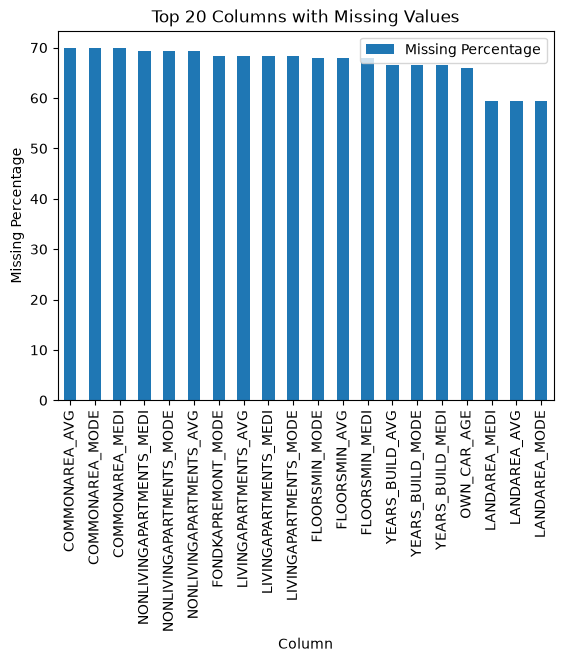

In [12]:
plt.figure(figsize=(12,6))

missing_values.head(20).plot(
    x="Column",
    y="Missing Percentage",
    kind="bar"
)

plt.title("Top 20 Columns with Missing Values")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=90)

plt.show()

In [13]:
missing_values[
    missing_values["Missing Percentage"] > 40
]

,Column,Missing Count,Missing Percentage
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953


In [14]:
missing_over_40 = missing_values[
    missing_values["Missing Percentage"] > 40
]

print("Columns > 40% missing:", len(missing_over_40))

missing_over_40

Columns > 40% missing: 49


,Column,Missing Count,Missing Percentage
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953


In [15]:
missing_values["Missing Category"] = pd.cut(
    missing_values["Missing Percentage"],
    bins=[0,5,20,40,60,100],
    labels=[
        "Low (0-5%)",
        "Moderate (5-20%)",
        "High (20-40%)",
        "Very High (40-60%)",
        "Extreme (>60%)"
    ]
)

missing_values["Missing Category"].value_counts()

Missing Category
Very High (40-60%)    32
Extreme (>60%)        17
Low (0-5%)            10
Moderate (5-20%)       7
High (20-40%)          1
Name: count, dtype: int64

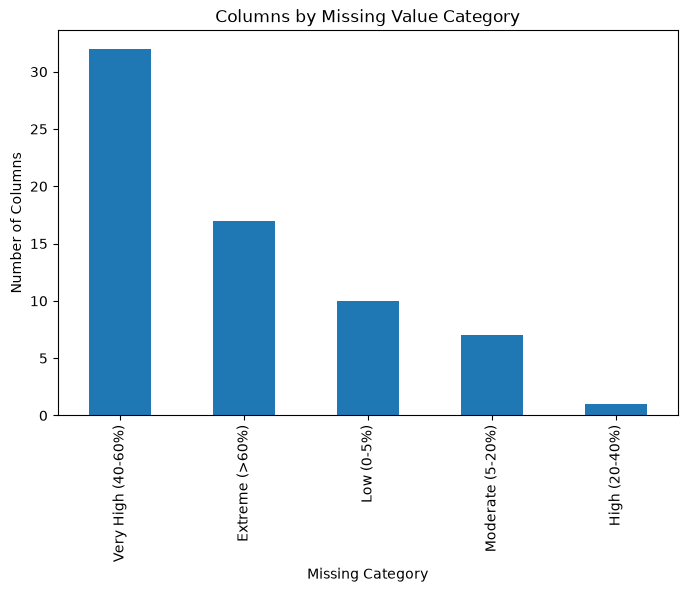

In [16]:
plt.figure(figsize=(8,5))

missing_values["Missing Category"]\
.value_counts()\
.plot(kind="bar")

plt.title("Columns by Missing Value Category")
plt.ylabel("Number of Columns")

plt.show()

In [17]:
application.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [18]:
data_dictionary = pd.DataFrame({
    "Column": application.columns,
    "Data_Type": application.dtypes.astype(str),
    "Missing_Count": application.isnull().sum().values,
    "Missing_Percentage": (
        application.isnull().sum().values
        / len(application)
    ) * 100,
    "Unique_Values": [
        application[col].nunique()
        for col in application.columns
    ]
})

data_dictionary.head()

,Column,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
SK_ID_CURR,SK_ID_CURR,int64,0,0.0,307511
TARGET,TARGET,int64,0,0.0,2
NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,str,0,0.0,2
CODE_GENDER,CODE_GENDER,str,0,0.0,3
FLAG_OWN_CAR,FLAG_OWN_CAR,str,0,0.0,2


In [19]:
data_dictionary.to_csv(
    "../docs/application_data_dictionary.csv",
    index=False
)

In [20]:
[col for col in application.columns if "ID" in col]

['SK_ID_CURR', 'DAYS_ID_PUBLISH']

In [21]:
num_cols = application.select_dtypes(
    include=["int64","float64"]
).columns

len(num_cols)

106

In [22]:
cat_cols = application.select_dtypes(
    include=["object"]
).columns

cat_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='str')

In [23]:
num_cols


Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='str', length=106)

In [24]:
application[
    [
        "TARGET",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "DAYS_BIRTH"
    ]
].describe()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH
count,307511.000000,3.075110e+05,3.075110e+05,307499.000000,307511.000000
mean,0.080729,1.687979e+05,5.990260e+05,27108.573909,-16036.995067
std,0.272419,2.371231e+05,4.024908e+05,14493.737315,4363.988632
min,0.000000,2.565000e+04,4.500000e+04,1615.500000,-25229.000000
25%,0.000000,1.125000e+05,2.700000e+05,16524.000000,-19682.000000
50%,0.000000,1.471500e+05,5.135310e+05,24903.000000,-15750.000000
75%,0.000000,2.025000e+05,8.086500e+05,34596.000000,-12413.000000
max,1.000000,1.170000e+08,4.050000e+06,258025.500000,-7489.000000


In [25]:
application[
    [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY"
    ]
].describe()

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
count,3.075110e+05,3.075110e+05,307499.000000
mean,1.687979e+05,5.990260e+05,27108.573909
std,2.371231e+05,4.024908e+05,14493.737315
min,2.565000e+04,4.500000e+04,1615.500000
25%,1.125000e+05,2.700000e+05,16524.000000
50%,1.471500e+05,5.135310e+05,24903.000000
75%,2.025000e+05,8.086500e+05,34596.000000
max,1.170000e+08,4.050000e+06,258025.500000


In [26]:
application["AGE"] = (
    abs(application["DAYS_BIRTH"]) / 365
)

In [27]:
application["AGE"].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE, dtype: float64

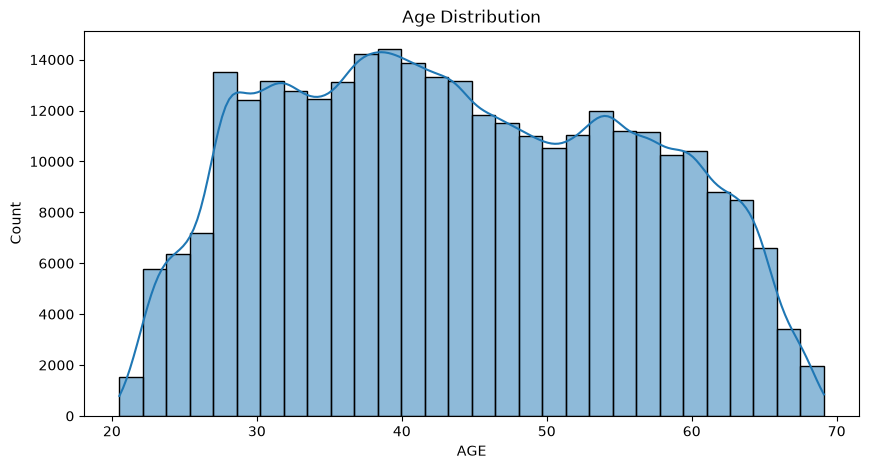

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    application["AGE"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

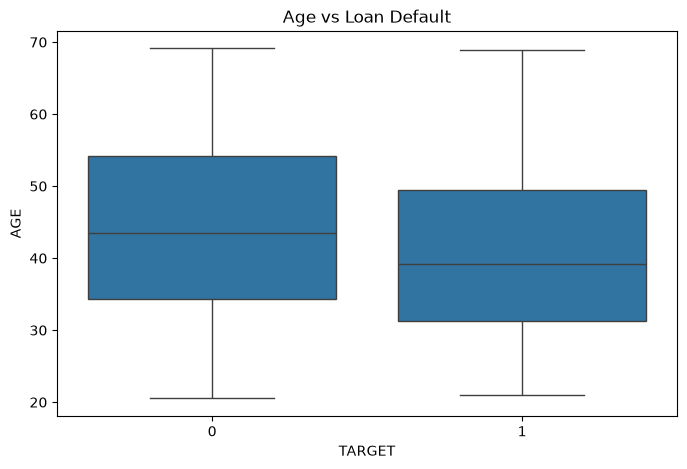

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=application,
    x="TARGET",
    y="AGE"
)

plt.title("Age vs Loan Default")
plt.show()

In [30]:
application.groupby("TARGET")["AGE"].mean()

TARGET
0    44.214182
1    40.780351
Name: AGE, dtype: float64

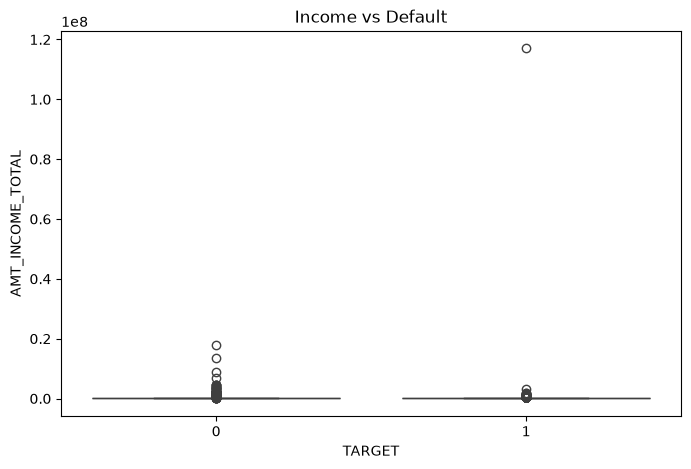

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=application,
    x="TARGET",
    y="AMT_INCOME_TOTAL"
)

plt.title("Income vs Default")
plt.show()

In [32]:
application["LOG_INCOME"] = np.log1p(
    application["AMT_INCOME_TOTAL"]
)

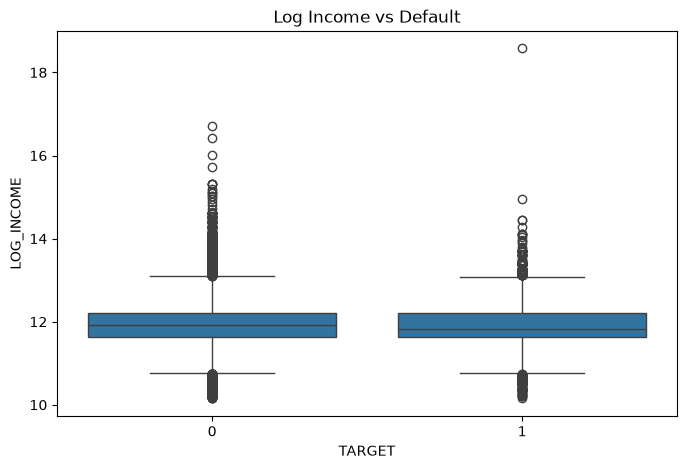

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=application,
    x="TARGET",
    y="LOG_INCOME"
)

plt.title("Log Income vs Default")
plt.show()

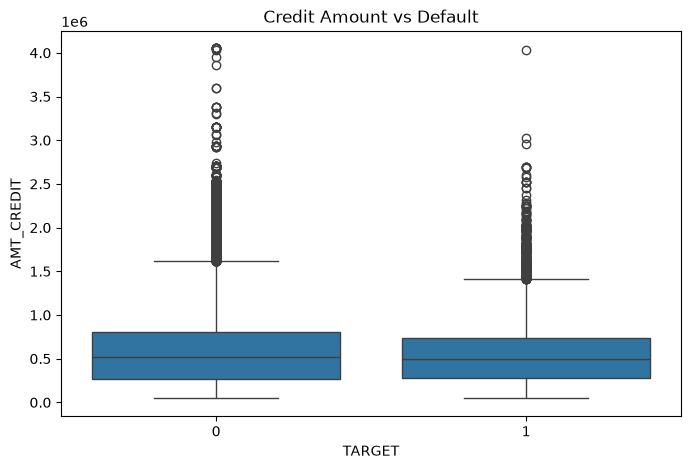

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=application,
    x="TARGET",
    y="AMT_CREDIT"
)

plt.title("Credit Amount vs Default")
plt.show()

In [35]:
application.groupby("TARGET")[
    [
        "AGE",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY"
    ]
].mean()

,AGE,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
TARGET,,,,
0,44.214182,169077.722266,602648.282002,27163.623349
1,40.780351,165611.760906,557778.527674,26481.744290


## Business Insights: Target Variable Analysis

### Age

Defaulters are younger on average than non-defaulters.

- Non-Defaulters: 44.21 years
- Defaulters: 40.78 years

This suggests that younger customers may have higher default risk.

### Income

The average income of defaulters is only slightly lower than non-defaulters.

- Non-Defaulters: 169,078
- Defaulters: 165,612

Income alone may not be a strong predictor of default.

### Credit Amount

Defaulters and non-defaulters have similar loan amounts.

Further investigation is required using loan-to-income ratios and credit history features.

### Initial Conclusion

Customer age appears to have stronger predictive power than income or loan amount at the aggregate level.

In [36]:
gender_default = pd.crosstab(
    application["CODE_GENDER"],
    application["TARGET"],
    normalize="index"
) * 100

gender_default

TARGET,0,1
CODE_GENDER,,
F,93.000672,6.999328
M,89.858080,10.141920
XNA,100.000000,0.000000


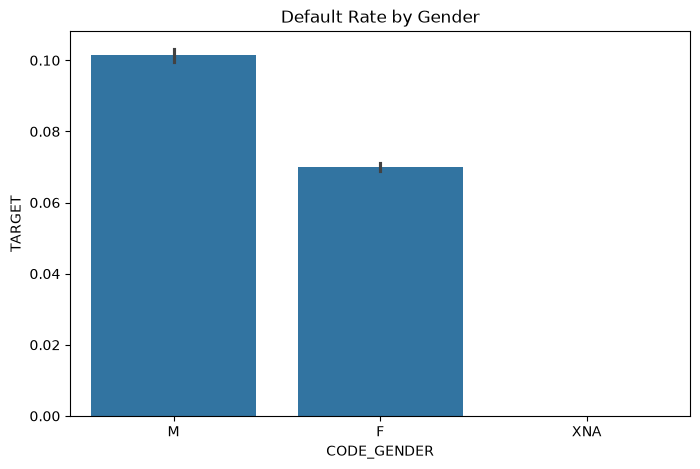

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=application,
    x="CODE_GENDER",
    y="TARGET"
)

plt.title("Default Rate by Gender")

plt.show()

In [38]:
education_default = pd.crosstab(
    application["NAME_EDUCATION_TYPE"],
    application["TARGET"],
    normalize="index"
) * 100

education_default.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
NAME_EDUCATION_TYPE,,
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929
Incomplete higher,91.515034,8.484966
Higher education,94.644885,5.355115
Academic degree,98.170732,1.829268


## Business Insights: Gender and Education

### Gender Analysis

Default rates differ significantly across genders.

| Gender | Default Rate |
|----------|----------:|
| Female | 7.00% |
| Male | 10.14% |

Male applicants exhibit higher credit risk compared to female applicants.

---

### Education Analysis

A strong inverse relationship exists between education level and default risk.

| Education Level | Default Rate |
|----------|----------:|
| Lower Secondary | 10.93% |
| Secondary Education | 8.94% |
| Incomplete Higher | 8.48% |
| Higher Education | 5.36% |
| Academic Degree | 1.83% |

Higher education levels are associated with significantly lower loan default rates.

---

### Key Finding

Education appears to be one of the strongest predictors of loan repayment behavior in the dataset.

In [39]:
occupation_default = pd.crosstab(
    application["OCCUPATION_TYPE"],
    application["TARGET"],
    normalize="index"
) * 100

occupation_default.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
OCCUPATION_TYPE,,
Low-skill Laborers,82.847587,17.152413
Drivers,88.673870,11.326130
Waiters/barmen staff,88.724036,11.275964
Security staff,89.257551,10.742449
Laborers,89.421230,10.578770
Cooking staff,89.556004,10.443996
Sales staff,90.368201,9.631799
Cleaning staff,90.393295,9.606705
Realty agents,92.143808,7.856192


In [40]:
income_type_default = pd.crosstab(
    application["NAME_INCOME_TYPE"],
    application["TARGET"],
    normalize="index"
) * 100

income_type_default.sort_values(
    by=1,
    ascending=False
)

TARGET,0,1
NAME_INCOME_TYPE,,
Maternity leave,60.000000,40.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472
Commercial associate,92.515743,7.484257
State servant,94.245035,5.754965
Pensioner,94.613634,5.386366
Businessman,100.000000,0.000000
Student,100.000000,0.000000


## Business Insights: Occupation and Income Type

### Occupation Risk Analysis

The highest default rates are observed among:

- Low-Skill Laborers (17.15%)
- Drivers (11.33%)
- Waiters/Barmen Staff (11.28%)
- Security Staff (10.74%)

The lowest default rates are observed among:

- Accountants (4.83%)
- High Skill Technical Staff (6.16%)
- Managers (6.21%)
- HR Staff (6.39%)

This suggests that occupation type is strongly associated with loan repayment behavior.

---

### Income Type Analysis

Customers with stable sources of income exhibit lower default rates.

| Income Type | Default Rate |
|-------------|-------------|
| Pensioner | 5.39% |
| State Servant | 5.75% |
| Commercial Associate | 7.48% |
| Working | 9.59% |

Government employees and pensioners appear to represent lower-risk customer segments.

In [41]:
missing_summary = (
    application.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_summary.head(30)

COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
COMMONAREA_MEDI             214865
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_AVG             204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_AVG                182590
LANDAREA_MODE               182590
BASEMENTAREA_AVG            179943
BASEMENTAREA_MODE           179943
BASEMENTAREA_MEDI           179943
EXT_SOURCE_1                173378
NONLIVINGAREA_MEDI          169682
NONLIVINGAREA_MODE          169682
NONLIVINGAREA_AVG           169682
ELEVATORS_AVG               163891
ELEVATORS_MEDI      

In [42]:
application.duplicated().sum()

np.int64(0)

In [43]:
application["SK_ID_CURR"].nunique()

307511

In [44]:
application["TARGET"].isnull().sum()

np.int64(0)

In [45]:
application.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.000000,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.000000,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.000000,270000.000000,513531.000000,808650.000000,4.050000e+06
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.000000,0.000000,0.000000,0.000000,2.700000e+01
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.000000,0.000000,0.000000,0.000000,2.610000e+02
AMT_REQ_CREDIT_BUREAU_YEAR,265992.0,1.899974,1.869295,0.000000,0.000000,1.000000,3.000000,2.500000e+01
AGE,307511.0,43.936973,11.956133,20.517808,34.008219,43.150685,53.923288,6.912055e+01


In [46]:
application["AMT_INCOME_TOTAL"].describe(
    percentiles=[0.25,0.5,0.75,0.90,0.95,0.99]
)

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
90%      2.700000e+05
95%      3.375000e+05
99%      4.725000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

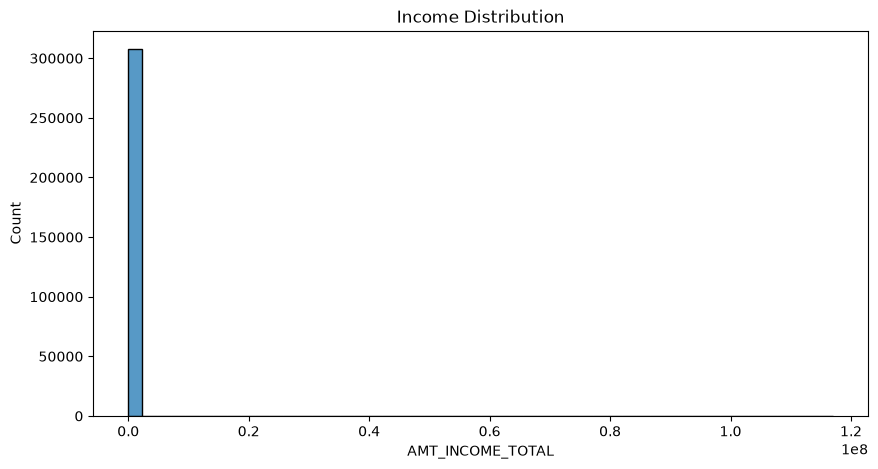

In [47]:
plt.figure(figsize=(10,5))

sns.histplot(
    application["AMT_INCOME_TOTAL"],
    bins=50
)

plt.title("Income Distribution")
plt.show()

In [48]:
application["LOG_INCOME"] = np.log1p(
    application["AMT_INCOME_TOTAL"]
)

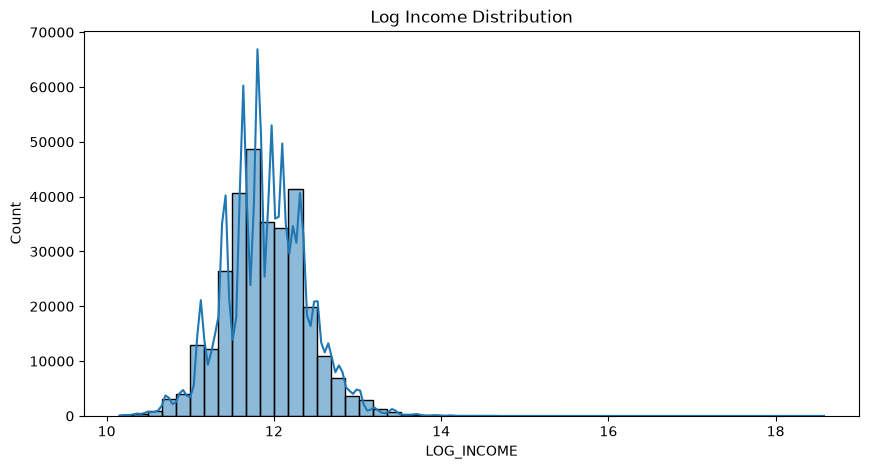

In [49]:
plt.figure(figsize=(10,5))

sns.histplot(
    application["LOG_INCOME"],
    bins=50,
    kde=True
)

plt.title("Log Income Distribution")
plt.show()

In [50]:
Q1 = application["AMT_INCOME_TOTAL"].quantile(0.25)

Q3 = application["AMT_INCOME_TOTAL"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

upper_limit

np.float64(337500.0)

In [51]:
(
    application["AMT_INCOME_TOTAL"]
    > upper_limit
).sum()

np.int64(14035)

## Data Cleaning Strategy

### Missing Values

Several variables contain significant missing values. Missing value treatment will be performed based on business relevance and percentage of missingness.

### Outliers

Income analysis revealed significant right-skewness and extreme values.

Key Findings:

- 99th Percentile Income: 472,500
- Maximum Income: 117,000,000
- Income Outliers: 14,035 records

### Decision

Outliers will not be removed because they may represent valid high-income customers.

Instead:

- Log transformation will be applied to highly skewed variables.
- Tree-based models such as Random Forest and XGBoost will naturally handle extreme values.

In [52]:
application["AGE_GROUP"] = pd.cut(
    application["AGE"],
    bins=[20,30,40,50,60,70],
    labels=[
        "20-30",
        "30-40",
        "40-50",
        "50-60",
        "60-70"
    ]
)

In [53]:
age_default = pd.crosstab(
    application["AGE_GROUP"],
    application["TARGET"],
    normalize="index"
) * 100

age_default.sort_values(by=1, ascending=False)

TARGET,0,1
AGE_GROUP,,
20-30,88.543124,11.456876
30-40,90.416484,9.583516
40-50,92.349198,7.650802
50-60,93.870295,6.129705
60-70,95.078558,4.921442


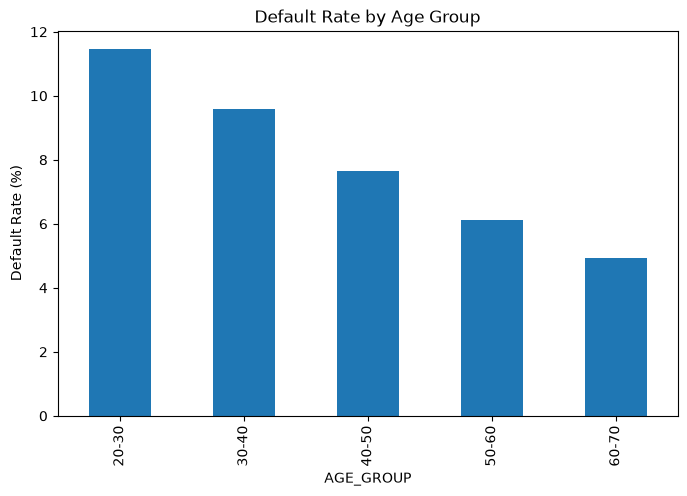

In [54]:
age_default[1].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate (%)")
plt.show()

## Business Insights: Age Risk Segmentation

A strong inverse relationship exists between age and default risk.

| Age Group | Default Rate |
|------------|------------|
| 20-30 | 11.46% |
| 30-40 | 9.58% |
| 40-50 | 7.65% |
| 50-60 | 6.13% |
| 60-70 | 4.92% |

### Key Finding

Younger customers exhibit significantly higher default rates.

Customers aged 20-30 are approximately 2.3 times more likely to default than customers aged 60-70.

### Business Implication

Age should be considered an important feature in credit risk assessment models.

In [55]:
eda_summary = pd.DataFrame({
    "Feature": [
        "Age",
        "Education",
        "Occupation",
        "Income Type",
        "Gender"
    ],
    "Finding": [
        "Younger customers default more",
        "Higher education lowers default risk",
        "Low skill laborers have highest risk",
        "Pensioners and state servants are lower risk",
        "Males default more frequently"
    ]
})

eda_summary

,Feature,Finding
0,Age,Younger customers default more
1,Education,Higher education lowers default risk
2,Occupation,Low skill laborers have highest risk
3,Income Type,Pensioners and state servants are lower risk
4,Gender,Males default more frequently


In [56]:
eda_summary.to_csv(
    "../reports/eda_key_findings.csv",
    index=False
)

In [57]:
application[["SK_ID_CURR"]].head()

,SK_ID_CURR
0,100002
1,100003
2,100004
3,100006
4,100007


In [58]:
bureau[["SK_ID_CURR", "SK_ID_BUREAU"]].head()

,SK_ID_CURR,SK_ID_BUREAU
0,215354,5714462
1,215354,5714463
2,215354,5714464
3,215354,5714465
4,215354,5714466


In [59]:
previous_application[["SK_ID_CURR", "SK_ID_PREV"]].head()

,SK_ID_CURR,SK_ID_PREV
0,271877,2030495
1,108129,2802425
2,122040,2523466
3,176158,2819243
4,202054,1784265


In [60]:
bureau.columns.tolist()

['SK_ID_CURR',
 'SK_ID_BUREAU',
 'CREDIT_ACTIVE',
 'CREDIT_CURRENCY',
 'DAYS_CREDIT',
 'CREDIT_DAY_OVERDUE',
 'DAYS_CREDIT_ENDDATE',
 'DAYS_ENDDATE_FACT',
 'AMT_CREDIT_MAX_OVERDUE',
 'CNT_CREDIT_PROLONG',
 'AMT_CREDIT_SUM',
 'AMT_CREDIT_SUM_DEBT',
 'AMT_CREDIT_SUM_LIMIT',
 'AMT_CREDIT_SUM_OVERDUE',
 'CREDIT_TYPE',
 'DAYS_CREDIT_UPDATE',
 'AMT_ANNUITY']

In [61]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [62]:
bureau_features = bureau.groupby(
    "SK_ID_CURR"
).agg({
    
    "SK_ID_BUREAU":"count",
    
    "AMT_CREDIT_SUM":"mean",
    
    "AMT_CREDIT_SUM_DEBT":"mean",
    
    "AMT_CREDIT_SUM_OVERDUE":"mean",
    
    "CREDIT_DAY_OVERDUE":"max",
    
    "CNT_CREDIT_PROLONG":"sum"
    
}).reset_index()

In [63]:
bureau_features.columns = [
    
    "SK_ID_CURR",
    
    "bureau_loan_count",
    
    "bureau_avg_credit",
    
    "bureau_avg_debt",
    
    "bureau_avg_overdue_amount",
    
    "bureau_max_days_overdue",
    
    "bureau_total_prolongations"
]

In [64]:
active_loans = bureau[
    bureau["CREDIT_ACTIVE"] == "Active"
]

In [65]:
active_count = active_loans.groupby(
    "SK_ID_CURR"
).size().reset_index(
    name="active_loan_count"
)

In [66]:
bureau_features = bureau_features.merge(
    active_count,
    on="SK_ID_CURR",
    how="left"
)

In [67]:
bureau_features

,SK_ID_CURR,bureau_loan_count,bureau_avg_credit,bureau_avg_debt,bureau_avg_overdue_amount,bureau_max_days_overdue,bureau_total_prolongations,active_loan_count
0,100001,7,2.076236e+05,85240.928571,0.0,0,0,3.0
1,100002,8,1.081319e+05,49156.200000,0.0,0,0,2.0
2,100003,4,2.543501e+05,0.000000,0.0,0,0,1.0
3,100004,2,9.451890e+04,0.000000,0.0,0,0,NaN
4,100005,3,2.190420e+05,189469.500000,0.0,0,0,2.0
...,...,...,...,...,...,...,...,...
305806,456249,13,2.841430e+05,16307.100000,0.0,0,0,2.0
305807,456250,3,1.028820e+06,744013.365000,0.0,0,0,2.0
305808,456253,4,9.900000e+05,448958.250000,0.0,0,0,2.0
305809,456254,1,4.500000e+04,0.000000,0.0,0,0,NaN


In [68]:
bureau_features[
    "active_loan_count"
] = bureau_features[
    "active_loan_count"
].fillna(0)

In [69]:
credit_types = bureau.groupby(
    "SK_ID_CURR"
)["CREDIT_TYPE"].nunique().reset_index()


In [70]:
credit_types.columns = [
    "SK_ID_CURR",
    "credit_type_count"
]

In [71]:
bureau_features = bureau_features.merge(
    credit_types,
    on="SK_ID_CURR",
    how="left"
)

In [72]:
bureau_features.head()

,SK_ID_CURR,bureau_loan_count,bureau_avg_credit,bureau_avg_debt,bureau_avg_overdue_amount,bureau_max_days_overdue,bureau_total_prolongations,active_loan_count,credit_type_count
0,100001,7,207623.571429,85240.928571,0.0,0,0,3.0,1
1,100002,8,108131.945625,49156.200000,0.0,0,0,2.0,2
2,100003,4,254350.125000,0.000000,0.0,0,0,1.0,2
3,100004,2,94518.900000,0.000000,0.0,0,0,0.0,1
4,100005,3,219042.000000,189469.500000,0.0,0,0,2.0,2


In [73]:
bureau_features.shape

(305811, 9)

In [74]:
bureau_features.to_csv(
    "../Data/processed/bureau_features.csv",
    index=False
)

In [75]:
previous_application.columns.tolist()

['SK_ID_PREV',
 'SK_ID_CURR',
 'NAME_CONTRACT_TYPE',
 'AMT_ANNUITY',
 'AMT_APPLICATION',
 'AMT_CREDIT',
 'AMT_DOWN_PAYMENT',
 'AMT_GOODS_PRICE',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'FLAG_LAST_APPL_PER_CONTRACT',
 'NFLAG_LAST_APPL_IN_DAY',
 'RATE_DOWN_PAYMENT',
 'RATE_INTEREST_PRIMARY',
 'RATE_INTEREST_PRIVILEGED',
 'NAME_CASH_LOAN_PURPOSE',
 'NAME_CONTRACT_STATUS',
 'DAYS_DECISION',
 'NAME_PAYMENT_TYPE',
 'CODE_REJECT_REASON',
 'NAME_TYPE_SUITE',
 'NAME_CLIENT_TYPE',
 'NAME_GOODS_CATEGORY',
 'NAME_PORTFOLIO',
 'NAME_PRODUCT_TYPE',
 'CHANNEL_TYPE',
 'SELLERPLACE_AREA',
 'NAME_SELLER_INDUSTRY',
 'CNT_PAYMENT',
 'NAME_YIELD_GROUP',
 'PRODUCT_COMBINATION',
 'DAYS_FIRST_DRAWING',
 'DAYS_FIRST_DUE',
 'DAYS_LAST_DUE_1ST_VERSION',
 'DAYS_LAST_DUE',
 'DAYS_TERMINATION',
 'NFLAG_INSURED_ON_APPROVAL']

In [76]:
previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
previous_application["NAME_CONTRACT_STATUS"].value_counts()

NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64

In [78]:
prev_count = previous_application.groupby(
    "SK_ID_CURR"
)["SK_ID_PREV"].count().reset_index()

prev_count.columns = [
    "SK_ID_CURR",
    "prev_application_count"
]

In [79]:
approved = previous_application[
    previous_application[
        "NAME_CONTRACT_STATUS"
    ] == "Approved"
]

In [80]:
approved_count = approved.groupby(
    "SK_ID_CURR"
).size().reset_index(
    name="approved_count"
)

In [81]:
refused = previous_application[
    previous_application[
        "NAME_CONTRACT_STATUS"
    ] == "Refused"
]

In [82]:
refused_count = refused.groupby(
    "SK_ID_CURR"
).size().reset_index(
    name="refused_count"
)

In [83]:
avg_credit = previous_application.groupby(
    "SK_ID_CURR"
)["AMT_CREDIT"].mean().reset_index()

avg_credit.columns = [
    "SK_ID_CURR",
    "prev_avg_credit"
]

In [84]:
avg_annuity = previous_application.groupby(
    "SK_ID_CURR"
)["AMT_ANNUITY"].mean().reset_index()

avg_annuity.columns = [
    "SK_ID_CURR",
    "prev_avg_annuity"
]

In [85]:
prev_features = prev_count.copy()

prev_features = prev_features.merge(
    approved_count,
    on="SK_ID_CURR",
    how="left"
)

prev_features = prev_features.merge(
    refused_count,
    on="SK_ID_CURR",
    how="left"
)

prev_features = prev_features.merge(
    avg_credit,
    on="SK_ID_CURR",
    how="left"
)

prev_features = prev_features.merge(
    avg_annuity,
    on="SK_ID_CURR",
    how="left"
)

In [86]:
prev_features.fillna(0, inplace=True)

,SK_ID_CURR,prev_application_count,approved_count,refused_count,prev_avg_credit,prev_avg_annuity
0,100001,1,1.0,0.0,23787.00,3951.000000
1,100002,1,1.0,0.0,179055.00,9251.775000
2,100003,3,3.0,0.0,484191.00,56553.990000
3,100004,1,1.0,0.0,20106.00,5357.250000
4,100005,2,1.0,0.0,20076.75,4813.200000
...,...,...,...,...,...,...
338852,456251,1,1.0,0.0,40455.00,6605.910000
338853,456252,1,1.0,0.0,56821.50,10074.465000
338854,456253,2,2.0,0.0,20625.75,4770.405000
338855,456254,2,2.0,0.0,134439.75,10681.132500


In [87]:
prev_features["approval_rate"] = (
    prev_features["approved_count"]
    /
    prev_features["prev_application_count"]
)

In [88]:
prev_features.shape

(338857, 7)

In [89]:
prev_features.head()

,SK_ID_CURR,prev_application_count,approved_count,refused_count,prev_avg_credit,prev_avg_annuity,approval_rate
0,100001,1,1.0,0.0,23787.00,3951.000,1.0
1,100002,1,1.0,0.0,179055.00,9251.775,1.0
2,100003,3,3.0,0.0,484191.00,56553.990,1.0
3,100004,1,1.0,0.0,20106.00,5357.250,1.0
4,100005,2,1.0,0.0,20076.75,4813.200,0.5


In [90]:
prev_features.to_csv(
    "../Data/processed/previous_application_features.csv",
    index=False
)

In [91]:
model_data = application.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left"
)

In [92]:
model_data.shape

(307511, 133)

In [93]:
model_data = model_data.merge(
    prev_features,
    on="SK_ID_CURR",
    how="left"
)

In [94]:
model_data.shape

(307511, 139)

In [95]:
new_cols = [
    'bureau_loan_count',
    'bureau_avg_credit',
    'bureau_avg_debt',
    'bureau_avg_overdue_amount',
    'bureau_max_days_overdue',
    'bureau_total_prolongations',
    'active_loan_count',
    'credit_type_count',
    'prev_application_count',
    'approved_count',
    'refused_count',
    'prev_avg_credit',
    'prev_avg_annuity',
    'approval_rate'
]

model_data[new_cols] = model_data[new_cols].fillna(0)

In [96]:
model_data[new_cols].isnull().sum()

bureau_loan_count             0
bureau_avg_credit             0
bureau_avg_debt               0
bureau_avg_overdue_amount     0
bureau_max_days_overdue       0
bureau_total_prolongations    0
active_loan_count             0
credit_type_count             0
prev_application_count        0
approved_count                0
refused_count                 0
prev_avg_credit               0
prev_avg_annuity              0
approval_rate                 0
dtype: int64

In [97]:
model_data.to_csv(
    "../Data/processed/model_data_v1.csv",
    index=False
)

In [98]:
model_data["credit_income_ratio"] = (
    model_data["AMT_CREDIT"]
    /
    model_data["AMT_INCOME_TOTAL"]
)

In [99]:
model_data["annuity_income_ratio"] = (
    model_data["AMT_ANNUITY"]
    /
    model_data["AMT_INCOME_TOTAL"]
)

In [100]:
model_data["debt_credit_ratio"] = np.where(
    model_data["bureau_avg_credit"] > 0,
    model_data["bureau_avg_debt"]
    /
    model_data["bureau_avg_credit"],
    0
)

In [101]:
model_data["active_loan_ratio"] = np.where(
    model_data["bureau_loan_count"] > 0,
    model_data["active_loan_count"]
    /
    model_data["bureau_loan_count"],
    0
)

In [102]:
model_data["refusal_rate"] = np.where(
    model_data["prev_application_count"] > 0,
    model_data["refused_count"]
    /
    model_data["prev_application_count"],
    0
)

In [103]:
model_data["credit_growth_ratio"] = np.where(
    model_data["prev_avg_credit"] > 0,
    model_data["AMT_CREDIT"]
    /
    model_data["prev_avg_credit"],
    0
)

In [104]:
ratio_features = [
    "credit_income_ratio",
    "annuity_income_ratio",
    "debt_credit_ratio",
    "active_loan_ratio",
    "refusal_rate",
    "credit_growth_ratio"
]

model_data[ratio_features].describe()

,credit_income_ratio,annuity_income_ratio,debt_credit_ratio,active_loan_ratio,refusal_rate,credit_growth_ratio
count,307511.000000,307499.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,3.957570,0.180930,0.272909,0.353855,0.104968,6.166527
std,2.689728,0.094574,0.457215,0.320026,0.181077,8.482077
min,0.004808,0.000224,-175.289231,0.000000,0.000000,0.000000
25%,2.018667,0.114782,0.000000,0.000000,0.000000,1.743865
50%,3.265067,0.162833,0.144552,0.333333,0.000000,3.537647
75%,5.159880,0.229067,0.486800,0.500000,0.176471,7.394550
max,84.736842,1.875965,8.098981,1.000000,1.000000,625.000000


In [105]:
model_data.groupby("TARGET")[
    ratio_features
].mean()

,credit_income_ratio,annuity_income_ratio,debt_credit_ratio,active_loan_ratio,refusal_rate,credit_growth_ratio
TARGET,,,,,,
0,3.963729,0.180530,0.266563,0.349236,0.100788,6.136904
1,3.887438,0.185482,0.345176,0.406454,0.152564,6.503849


# Phase 3: Data Validation & Preprocessing Strategy

## Objective

Before training any machine learning model, the engineered dataset must be validated to ensure data quality, consistency, and suitability for predictive modeling.

The following checks will be performed:

1. Dataset dimensions
2. Duplicate records
3. Missing value assessment
4. Data type validation
5. Target variable validation
6. Feature leakage assessment
7. Feature categorization
8. Preprocessing strategy

In [106]:
print("=" * 60)
print("MODEL DATASET VALIDATION")
print("=" * 60)

print(f"Rows    : {model_data.shape[0]:,}")
print(f"Columns : {model_data.shape[1]}")

print("\nTarget Distribution")
print(model_data["TARGET"].value_counts())

print("\nDuplicate Rows")
print(model_data.duplicated().sum())

print("\nUnique Customers")
print(model_data["SK_ID_CURR"].nunique())

MODEL DATASET VALIDATION
Rows    : 307,511
Columns : 145

Target Distribution
TARGET
0    282686
1     24825
Name: count, dtype: int64

Duplicate Rows
0

Unique Customers
307511


In [107]:
missing_report = (
    pd.DataFrame({
        "Feature": model_data.columns,
        "Missing Count": model_data.isnull().sum().values,
        "Missing %": (
            model_data.isnull().sum().values / len(model_data)
        ) * 100,
        "Data Type": model_data.dtypes.astype(str).values
    })
    .sort_values("Missing %", ascending=False)
)

missing_report.head(25)

,Feature,Missing Count,Missing %,Data Type
48,COMMONAREA_AVG,214865,69.872297,float64
62,COMMONAREA_MODE,214865,69.872297,float64
76,COMMONAREA_MEDI,214865,69.872297,float64
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963,float64
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963,float64
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963,float64
86,FONDKAPREMONT_MODE,210295,68.386172,str
54,LIVINGAPARTMENTS_AVG,210199,68.354953,float64
68,LIVINGAPARTMENTS_MODE,210199,68.354953,float64
82,LIVINGAPARTMENTS_MEDI,210199,68.354953,float64


In [108]:
numeric_features = model_data.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = model_data.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numeric Features    : {len(numeric_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numeric Features    : 128
Categorical Features: 16


## Data Leakage Assessment

Data leakage occurs when information unavailable at prediction time is used during model training.

Such features artificially inflate model performance and lead to unrealistic results.

Potential leakage features will be identified and removed before model development.

In [109]:
potential_leakage = [
    col for col in model_data.columns
    if (
        "TARGET" in col
        or "DAYS_ENDDATE_FACT" in col
        or "DAYS_TERMINATION" in col
        or "DAYS_LAST_DUE" in col
        or "DAYS_FIRST_DRAWING" in col
    )
]

potential_leakage

['TARGET']

In [110]:
feature_inventory = pd.DataFrame({
    "Feature": model_data.columns,
    "Type": model_data.dtypes.astype(str),
    "Missing %": (
        model_data.isnull().mean() * 100
    ).round(2),
    "Unique Values": model_data.nunique()
})

feature_inventory.head()

,Feature,Type,Missing %,Unique Values
SK_ID_CURR,SK_ID_CURR,int64,0.0,307511
TARGET,TARGET,int64,0.0,2
NAME_CONTRACT_TYPE,NAME_CONTRACT_TYPE,str,0.0,2
CODE_GENDER,CODE_GENDER,str,0.0,3
FLAG_OWN_CAR,FLAG_OWN_CAR,str,0.0,2


In [111]:
feature_inventory.to_csv(
    "../reports/feature_inventory.csv",
    index=False
)

In [112]:
experiment_tracker = pd.DataFrame(columns=[
    "Experiment_ID",
    "Dataset_Version",
    "Feature_Count",
    "Model",
    "Sampling",
    "Scaler",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "Comments"
])

experiment_tracker

,Experiment_ID,Dataset_Version,Feature_Count,Model,Sampling,Scaler,Accuracy,Precision,Recall,F1,ROC_AUC,Comments


In [113]:
missing_report = pd.DataFrame({
    "Feature": model_data.columns,
    "Missing Count": model_data.isnull().sum().values,
    "Missing %": (
        model_data.isnull().sum().values / len(model_data)
    ) * 100,
    "Data Type": model_data.dtypes.astype(str).values
})

missing_report = missing_report.sort_values(
    by="Missing %",
    ascending=False
)

missing_report.head(20)

,Feature,Missing Count,Missing %,Data Type
48,COMMONAREA_AVG,214865,69.872297,float64
62,COMMONAREA_MODE,214865,69.872297,float64
76,COMMONAREA_MEDI,214865,69.872297,float64
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963,float64
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963,float64
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963,float64
86,FONDKAPREMONT_MODE,210295,68.386172,str
54,LIVINGAPARTMENTS_AVG,210199,68.354953,float64
68,LIVINGAPARTMENTS_MODE,210199,68.354953,float64
82,LIVINGAPARTMENTS_MEDI,210199,68.354953,float64


In [114]:
potential_leakage

['TARGET']

In [115]:
high_missing = [
    "COMMONAREA_AVG",
    "COMMONAREA_MODE",
    "COMMONAREA_MEDI",
    "NONLIVINGAPARTMENTS_AVG",
    "NONLIVINGAPARTMENTS_MODE",
    "NONLIVINGAPARTMENTS_MEDI",
    "FONDKAPREMONT_MODE",
    "LIVINGAPARTMENTS_AVG",
    "LIVINGAPARTMENTS_MODE",
    "LIVINGAPARTMENTS_MEDI",
    "FLOORSMIN_AVG",
    "FLOORSMIN_MODE",
    "FLOORSMIN_MEDI",
    "YEARS_BUILD_AVG",
    "YEARS_BUILD_MODE",
    "YEARS_BUILD_MEDI",
    "OWN_CAR_AGE",
    "LANDAREA_AVG",
    "LANDAREA_MODE",
    "LANDAREA_MEDI"
]

model_data[high_missing].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
COMMONAREA_AVG,92646.0,NaN,NaN,NaN,0.044621,0.076036,0.0,0.0078,0.0211,0.0515,1.0
COMMONAREA_MODE,92646.0,NaN,NaN,NaN,0.042553,0.074445,0.0,0.0072,0.019,0.049,1.0
COMMONAREA_MEDI,92646.0,NaN,NaN,NaN,0.044595,0.076144,0.0,0.0079,0.0208,0.0513,1.0
NONLIVINGAPARTMENTS_AVG,93997.0,NaN,NaN,NaN,0.008809,0.047732,0.0,0.0,0.0,0.0039,1.0
NONLIVINGAPARTMENTS_MODE,93997.0,NaN,NaN,NaN,0.008076,0.046276,0.0,0.0,0.0,0.0039,1.0
NONLIVINGAPARTMENTS_MEDI,93997.0,NaN,NaN,NaN,0.008651,0.047415,0.0,0.0,0.0,0.0039,1.0
FONDKAPREMONT_MODE,97216,4,reg oper account,73830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LIVINGAPARTMENTS_AVG,97312.0,NaN,NaN,NaN,0.100775,0.092576,0.0,0.0504,0.0756,0.121,1.0
LIVINGAPARTMENTS_MODE,97312.0,NaN,NaN,NaN,0.105645,0.09788,0.0,0.0542,0.0771,0.1313,1.0
LIVINGAPARTMENTS_MEDI,97312.0,NaN,NaN,NaN,0.101954,0.093642,0.0,0.0513,0.0761,0.1231,1.0


In [116]:
high_missing_corr = model_data[
    high_missing + ["TARGET"]
].corr(numeric_only=True)["TARGET"].sort_values(
    key=abs,
    ascending=False
)

high_missing_corr

TARGET                      1.000000
OWN_CAR_AGE                 0.037612
FLOORSMIN_AVG              -0.033614
FLOORSMIN_MEDI             -0.033394
FLOORSMIN_MODE             -0.032698
LIVINGAPARTMENTS_AVG       -0.025031
LIVINGAPARTMENTS_MEDI      -0.024621
LIVINGAPARTMENTS_MODE      -0.023393
YEARS_BUILD_MEDI           -0.022326
YEARS_BUILD_AVG            -0.022149
YEARS_BUILD_MODE           -0.022068
COMMONAREA_MEDI            -0.018573
COMMONAREA_AVG             -0.018550
COMMONAREA_MODE            -0.016340
LANDAREA_MEDI              -0.011256
LANDAREA_AVG               -0.010885
LANDAREA_MODE              -0.010174
NONLIVINGAPARTMENTS_AVG    -0.003176
NONLIVINGAPARTMENTS_MEDI   -0.002757
NONLIVINGAPARTMENTS_MODE   -0.001557
Name: TARGET, dtype: float64

In [117]:
#merge the missing_report with high_missing_corr
merged_report = pd.merge(
    missing_report[missing_report['Feature'].isin(high_missing)],
    pd.DataFrame({
        "Feature": high_missing,
        "Correlation": high_missing_corr.values
    }),
    on="Feature"
)
merged_report[['Feature', 'Missing Count', 'Missing %', 'Correlation']]

,Feature,Missing Count,Missing %,Correlation
0,COMMONAREA_AVG,214865,69.872297,1.000000
1,COMMONAREA_MODE,214865,69.872297,0.037612
2,COMMONAREA_MEDI,214865,69.872297,-0.033614
3,NONLIVINGAPARTMENTS_MODE,213514,69.432963,-0.032698
4,NONLIVINGAPARTMENTS_AVG,213514,69.432963,-0.033394
5,NONLIVINGAPARTMENTS_MEDI,213514,69.432963,-0.025031
6,FONDKAPREMONT_MODE,210295,68.386172,-0.024621
7,LIVINGAPARTMENTS_AVG,210199,68.354953,-0.023393
8,LIVINGAPARTMENTS_MODE,210199,68.354953,-0.022326
9,LIVINGAPARTMENTS_MEDI,210199,68.354953,-0.022149


## Missing Value Treatment Strategy

Instead of removing variables solely based on missing value percentage, feature selection will follow a multi-stage approach.

Each feature will be evaluated based on:

1. Business relevance
2. Missing value percentage
3. Predictive relationship with the target
4. Model-based feature importance

This approach minimizes the risk of removing variables that may contain valuable predictive information despite having high missingness.

# Phase 4: Data Preprocessing Pipeline

## Objective

The purpose of preprocessing is to transform the engineered dataset into a machine-learning-ready format while preventing data leakage.

The preprocessing pipeline will:

- Separate features and target
- Perform train-test split
- Identify numerical and categorical variables
- Impute missing values
- Encode categorical variables
- Standardize numerical variables where required
- Produce a reusable preprocessing pipeline

In [118]:
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn import set_config

set_config(display="diagram")

In [119]:
X = model_data.drop(columns=["TARGET"])

y = model_data["TARGET"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (307511, 144)
Target Shape         : (307511,)


In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [121]:
print("=" * 60)
print("TRAIN TEST SPLIT")
print("=" * 60)

print(f"Training Samples : {X_train.shape[0]:,}")
print(f"Testing Samples  : {X_test.shape[0]:,}")

print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True) * 100)

TRAIN TEST SPLIT
Training Samples : 246,008
Testing Samples  : 61,503

Training Target Distribution
TARGET
0    91.927092
1     8.072908
Name: proportion, dtype: float64

Testing Target Distribution
TARGET
0    91.927223
1     8.072777
Name: proportion, dtype: float64


In [122]:
# Numerical Features
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Categorical Features
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("="*60)
print("FEATURE SUMMARY")
print("="*60)

print(f"Numerical Features   : {len(numeric_features)}")
print(f"Categorical Features : {len(categorical_features)}")

print("\nFirst 10 Numerical Features")
print(numeric_features[:10])

print("\nCategorical Features")
print(categorical_features)

FEATURE SUMMARY
Numerical Features   : 127
Categorical Features : 16

First 10 Numerical Features
['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION']

Categorical Features
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [123]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

numeric_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness des

In [124]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

categorical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('encoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto ac

## Feature Audit

Before model training, feature types were reviewed.

The following feature was excluded:

| Feature | Reason |
|----------|--------|
| SK_ID_CURR | Unique customer identifier. Used only for record identification and has no predictive value. |

The identifier will be retained separately for prediction tracking but excluded from model training.

In [125]:
# Keep customer IDs separately
train_ids = X_train["SK_ID_CURR"].copy()
test_ids = X_test["SK_ID_CURR"].copy()

# Remove ID column from training data
X_train = X_train.drop(columns=["SK_ID_CURR"])
X_test = X_test.drop(columns=["SK_ID_CURR"])

In [126]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print(f"Numeric Features: {len(numeric_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numeric Features: 126
Categorical Features: 16


In [127]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [128]:
# Learn preprocessing parameters from training data only
preprocessor.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [129]:
X_train_processed = preprocessor.transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [130]:
print("="*60)
print("PREPROCESSED DATASET")
print("="*60)

print("Training Shape :", X_train_processed.shape)
print("Testing Shape  :", X_test_processed.shape)

PREPROCESSED DATASET
Training Shape : (246008, 266)
Testing Shape  : (61503, 266)


In [131]:
feature_names = preprocessor.get_feature_names_out()

print(f"Total Processed Features: {len(feature_names)}")

Total Processed Features: 266


In [132]:
feature_names[:100]

array(['num__CNT_CHILDREN', 'num__AMT_INCOME_TOTAL', 'num__AMT_CREDIT',
       'num__AMT_ANNUITY', 'num__AMT_GOODS_PRICE',
       'num__REGION_POPULATION_RELATIVE', 'num__DAYS_BIRTH',
       'num__DAYS_EMPLOYED', 'num__DAYS_REGISTRATION',
       'num__DAYS_ID_PUBLISH', 'num__OWN_CAR_AGE', 'num__FLAG_MOBIL',
       'num__FLAG_EMP_PHONE', 'num__FLAG_WORK_PHONE',
       'num__FLAG_CONT_MOBILE', 'num__FLAG_PHONE', 'num__FLAG_EMAIL',
       'num__CNT_FAM_MEMBERS', 'num__REGION_RATING_CLIENT',
       'num__REGION_RATING_CLIENT_W_CITY', 'num__HOUR_APPR_PROCESS_START',
       'num__REG_REGION_NOT_LIVE_REGION',
       'num__REG_REGION_NOT_WORK_REGION',
       'num__LIVE_REGION_NOT_WORK_REGION', 'num__REG_CITY_NOT_LIVE_CITY',
       'num__REG_CITY_NOT_WORK_CITY', 'num__LIVE_CITY_NOT_WORK_CITY',
       'num__EXT_SOURCE_1', 'num__EXT_SOURCE_2', 'num__EXT_SOURCE_3',
       'num__APARTMENTS_AVG', 'num__BASEMENTAREA_AVG',
       'num__YEARS_BEGINEXPLUATATION_AVG', 'num__YEARS_BUILD_AVG',
       'num_

In [133]:
X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

In [134]:
print("="*60)
print("POST-PROCESSING VALIDATION")
print("="*60)

print("Missing Values (Train):", X_train_processed.isnull().sum().sum())
print("Missing Values (Test):", X_test_processed.isnull().sum().sum())

print("Training Shape:", X_train_processed.shape)
print("Testing Shape :", X_test_processed.shape)

POST-PROCESSING VALIDATION
Missing Values (Train): 0
Missing Values (Test): 0
Training Shape: (246008, 266)
Testing Shape : (61503, 266)


## Preprocessing Summary

The preprocessing pipeline was fitted using only the training dataset to prevent data leakage.

The following transformations were applied:

- Median imputation for numerical variables.
- Most frequent imputation for categorical variables.
- One-Hot Encoding for categorical features.
- Automatic feature expansion using ColumnTransformer.

After preprocessing:

- No missing values remain.
- All categorical variables are encoded.
- The dataset is ready for machine learning algorithms.

# Phase 5: Model Development

## Objective

This phase focuses on building, training, evaluating, and comparing multiple machine learning models.

A reusable experiment framework will be created to ensure that every model is evaluated consistently using the same metrics and validation strategy.

The models will be compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Cross Validation
- Confusion Matrix
- ROC Curve

In [135]:
# =====================================================
# PROJECT CONFIGURATION
# =====================================================

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

SCORING = "roc_auc"

print("Configuration Loaded Successfully")

Configuration Loaded Successfully


In [136]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold
)

In [137]:
experiment_tracker = pd.DataFrame(
    columns=[
        "Experiment",

        "Model",

        "Scaling",

        "SMOTE",

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC_AUC",

        "CV_ROC_AUC",

        "Comments"
    ]
)

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments


In [ ]:
def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):
    """
    Train and evaluate a classification model.
    """

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # Print
    print("="*60)

    print(model.__class__.__name__)

    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")

    print(f"Precision: {precision:.4f}")

    print(f"Recall   : {recall:.4f}")

    print(f"F1 Score : {f1:.4f}")

    print(f"ROC AUC  : {roc_auc:.4f}")

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "predictions": y_pred,
        "probabilities": y_prob
    }

In [ ]:
def cross_validation_score(
    model,
    X_train,
    y_train
):

    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=SCORING,
        n_jobs=-1
    )

    print("="*60)
    print("Cross Validation")
    print("="*60)

    print(scores)

    print()

    print(f"Mean ROC-AUC : {scores.mean():.4f}")

    print(f"Std Dev      : {scores.std():.4f}")

    return scores

In [140]:
numeric_transformer_scaled = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [141]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_scaled,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [142]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_scaled
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=1000,
                class_weight=None
            )
        )
    ]
)

In [143]:
logistic_results = evaluate_model(
    logistic_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

Pipeline
Accuracy : 0.9195
Precision: 0.5376
Recall   : 0.0187
F1 Score : 0.0362
ROC AUC  : 0.7587


In [144]:
logistic_cv = cross_validation_score(
    logistic_pipeline,
    X_train,
    y_train
)

Cross Validation
[0.75240869 0.75346825 0.75879575 0.7519025  0.75258041]

Mean ROC-AUC : 0.7538
Std Dev      : 0.0025


In [145]:
experiment_tracker.loc[len(experiment_tracker)] = {
    "Experiment": "E1",
    "Model": "Logistic Regression",
    "Scaling": "Yes",
    "SMOTE": "No",
    "Accuracy": logistic_results["accuracy"],
    "Precision": logistic_results["precision"],
    "Recall": logistic_results["recall"],
    "F1": logistic_results["f1"],
    "ROC_AUC": logistic_results["roc_auc"],
    "CV_ROC_AUC": logistic_cv.mean(),
    "Comments": "Baseline Model"
}

In [146]:
experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model


# Experiment E2 - Logistic Regression with Class Weights

## Objective

The baseline Logistic Regression model demonstrated a good ROC-AUC score but extremely poor recall for the minority class.

To improve the model's ability to identify defaulting customers, class weights are introduced.

The parameter `class_weight="balanced"` automatically assigns higher importance to the minority class during optimization.

This experiment evaluates whether class weighting improves recall without significantly degrading overall model performance.

In [147]:
logistic_balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_scaled
        ),
        (
            "classifier",
            LogisticRegression(
                random_state=RANDOM_STATE,
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

logistic_balanced_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [148]:
logistic_balanced_results = evaluate_model(
    logistic_balanced_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

Pipeline
Accuracy : 0.6960
Precision: 0.1663
Recall   : 0.6892
F1 Score : 0.2680
ROC AUC  : 0.7590


In [149]:
logistic_balanced_cv = cross_validation_score(
    logistic_balanced_pipeline,
    X_train,
    y_train
)

Cross Validation
[0.75450498 0.75389172 0.75936092 0.75238583 0.75368868]

Mean ROC-AUC : 0.7548
Std Dev      : 0.0024


In [150]:
experiment_tracker.loc[len(experiment_tracker)] = {
    "Experiment": "E2",
    "Model": "Logistic Regression (Balanced)",
    "Scaling": "Yes",
    "SMOTE": "No",
    "Accuracy": logistic_balanced_results["accuracy"],
    "Precision": logistic_balanced_results["precision"],
    "Recall": logistic_balanced_results["recall"],
    "F1": logistic_balanced_results["f1"],
    "ROC_AUC": logistic_balanced_results["roc_auc"],
    "CV_ROC_AUC": logistic_balanced_cv.mean(),
    "Comments": "Applied class_weight='balanced'"
}

In [151]:
experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'


## Experiment E2 Analysis

### Objective

Evaluate whether assigning higher importance to the minority class improves the model's ability to detect loan defaults.

### Results

- Accuracy decreased from **91.95%** to **69.60%**.
- Recall increased dramatically from **1.87%** to **68.92%**.
- Precision decreased from **53.76%** to **16.63%**.
- ROC-AUC remained nearly unchanged (**0.7587 → 0.7590**).

### Business Interpretation

The balanced model detects substantially more defaulting customers, making it more suitable for credit risk prediction. Although more low-risk applicants are incorrectly flagged, this trade-off is acceptable because the financial cost of approving a defaulting customer is significantly greater than the cost of performing additional manual reviews.

### Conclusion

For credit risk assessment, the balanced Logistic Regression model is preferred over the default Logistic Regression model due to its significantly higher recall.

# Experiment E3 - Threshold Optimization

## Objective

The previous experiment demonstrated that class weighting significantly improved recall while reducing precision.

Since Logistic Regression predicts probabilities, the decision threshold can be adjusted to optimize business objectives.

This experiment evaluates multiple classification thresholds to identify the most appropriate balance between Precision and Recall for credit risk assessment.

In [152]:
# Predicted probability of default
y_prob = logistic_balanced_pipeline.predict_proba(X_test)[:, 1]

In [153]:
y_prob

array([0.36204394, 0.28403663, 0.73787656, ..., 0.32007128, 0.63200058,
       0.67202838], shape=(61503,))

In [154]:
threshold_results = []

thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred)

    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.2,0.239809,0.093500,0.967976,0.170528
1,0.3,0.407492,0.111867,0.913595,0.199328
2,0.4,0.566054,0.135210,0.810876,0.231772
3,0.5,0.695999,0.166310,0.689225,0.267961
4,0.6,0.797197,0.207587,0.536757,0.299388
5,0.7,0.864917,0.257296,0.356898,0.299021


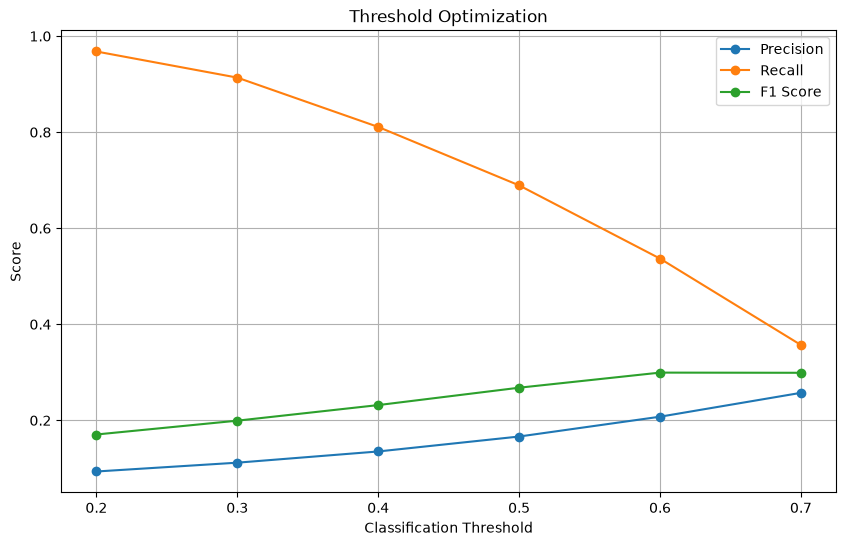

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

## Experiment E3 Analysis

### Objective

Evaluate how changing the classification threshold affects the trade-off between Precision and Recall.

### Results

- Lower thresholds significantly improved Recall but reduced Precision.
- Higher thresholds increased Precision while decreasing Recall.
- The highest F1 Score was achieved at a threshold of **0.60**.

### Business Interpretation

Threshold selection should depend on business priorities.

- Lower thresholds are appropriate when minimizing missed defaulters is the primary objective.
- Higher thresholds reduce false alarms but increase the risk of approving defaulting customers.

For this project, a threshold of **0.60** provides the most balanced trade-off between identifying risky applicants and limiting unnecessary manual reviews.

### Conclusion

Threshold optimization demonstrated that the default threshold of **0.50** is not always optimal. Adjusting the decision threshold can significantly improve the operational usefulness of the model without changing the underlying algorithm.

# Experiment E4 - Decision Tree Classifier

## Objective

The previous experiments focused on improving the performance of Logistic Regression using class weighting and threshold optimization.

Although these techniques significantly improved the model's ability to detect defaulting customers, Logistic Regression is inherently a linear algorithm and may not fully capture the complex relationships present in credit risk data.

This experiment evaluates a Decision Tree Classifier to determine whether a non-linear model can better learn the interactions between customer characteristics, financial information, and historical credit behavior.

The objective is to compare the Decision Tree model against the Logistic Regression experiments using the same evaluation framework and determine whether it provides improved predictive performance for loan default prediction.

In [156]:
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn import tree

In [157]:
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                random_state=RANDOM_STATE
            )
        )
    ]
)

decision_tree_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [158]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import matplotlib.pyplot as plt


def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test
):
    """
    Train and evaluate a binary classification model.
    """

    # ==========================
    # Train Model
    # ==========================
    model.fit(X_train, y_train)

    # ==========================
    # Predictions
    # ==========================
    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    # ==========================
    # Metrics
    # ==========================
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # ==========================
    # Print Metrics
    # ==========================

    print("=" * 60)
    print(model.named_steps["classifier"].__class__.__name__)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {roc_auc:.4f}")

    # ==========================
    # Classification Report
    # ==========================

    print("\n")
    print("=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)

    print(classification_report(y_test, y_pred))

    # ==========================
    # Confusion Matrix
    # ==========================

    plt.figure(figsize=(6, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title("Confusion Matrix")

    plt.show()

    # ==========================
    # ROC Curve
    # ==========================

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title("ROC Curve")

    plt.show()

    # ==========================
    # Precision Recall Curve
    # ==========================

    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob
    )

    plt.title("Precision-Recall Curve")

    plt.show()

    return {

    "model": model,

    "accuracy": accuracy,

    "precision": precision,

    "recall": recall,

    "f1": f1,

    "roc_auc": roc_auc,

    "predictions": y_pred,

    "probabilities": y_prob

}


In [159]:
def cross_validation_score(
    model,
    X_train,
    y_train
):

    cv = StratifiedKFold(
        n_splits=CV_FOLDS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    print("=" * 60)
    print("5-FOLD STRATIFIED CROSS VALIDATION")
    print("=" * 60)

    print(scores)

    print()

    print(f"Mean ROC-AUC : {scores.mean():.4f}")

    print(f"Std Dev      : {scores.std():.4f}")

    return scores

DecisionTreeClassifier
Accuracy : 0.8549
Precision: 0.1519
Recall   : 0.1740
F1 Score : 0.1622
ROC AUC  : 0.5443


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.91      0.92     56538
           1       0.15      0.17      0.16      4965

    accuracy                           0.85     61503
   macro avg       0.54      0.54      0.54     61503
weighted avg       0.86      0.85      0.86     61503



<Figure size 600x500 with 0 Axes>

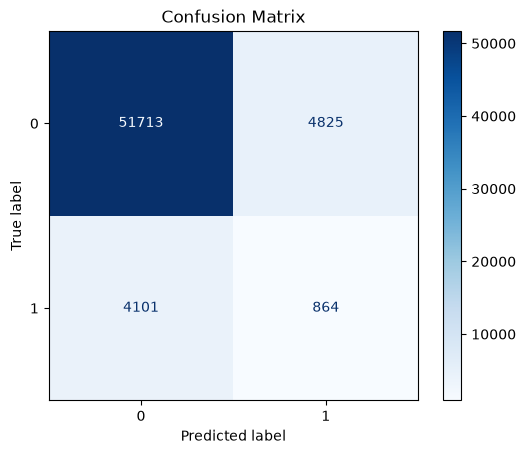

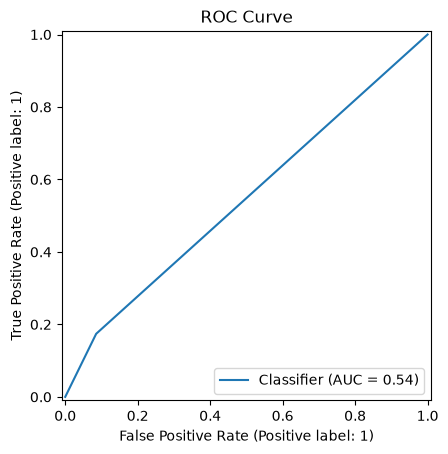

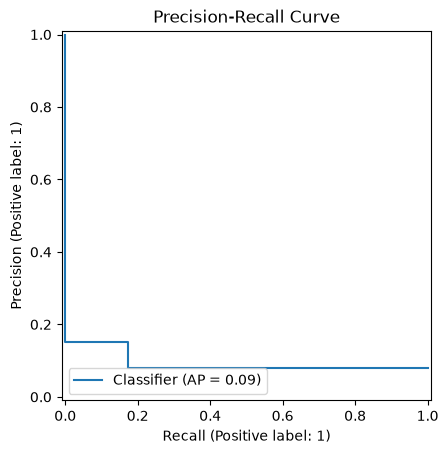

In [160]:
decision_tree_results = evaluate_model(
    decision_tree_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)


In [161]:
decision_tree_cv = cross_validation_score(
    decision_tree_pipeline,
    X_train,
    y_train
)

5-FOLD STRATIFIED CROSS VALIDATION
[0.53777263 0.5429038  0.53700592 0.53810831 0.53848951]

Mean ROC-AUC : 0.5389
Std Dev      : 0.0021


In [162]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E4",

    "Model": "Decision Tree",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": decision_tree_results["accuracy"],

    "Precision": decision_tree_results["precision"],

    "Recall": decision_tree_results["recall"],

    "F1": decision_tree_results["f1"],

    "ROC_AUC": decision_tree_results["roc_auc"],

    "CV_ROC_AUC": decision_tree_cv.mean(),

    "Comments": "Baseline Decision Tree"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree


## Experiment E4 Analysis

### Objective

Evaluate whether a Decision Tree Classifier can improve loan default prediction by learning non-linear relationships in the data.

### Results

- Accuracy: **85.49%**
- Precision: **15.19%**
- Recall: **17.40%**
- F1 Score: **16.22%**
- ROC-AUC: **0.5443**
- Cross Validation ROC-AUC: **0.5389**

### Business Interpretation

The baseline Decision Tree failed to outperform the Logistic Regression models. Although it identified some defaulting customers, its ability to distinguish between default and non-default applicants was only marginally better than random guessing.

The ROC-AUC of approximately **0.54** indicates poor ranking capability, making the baseline Decision Tree unsuitable for credit risk assessment.

### Conclusion

The baseline Decision Tree does not provide satisfactory predictive performance. However, Decision Trees are highly sensitive to hyperparameter settings. Further experiments involving tree pruning and hyperparameter tuning will be performed before concluding on the suitability of tree-based methods.

# Experiment E5 - Optimized Decision Tree

## Objective

The baseline Decision Tree model demonstrated poor predictive performance and failed to outperform the Logistic Regression models. The model showed a low ROC-AUC score, indicating that the default hyperparameter configuration was unable to effectively separate defaulting and non-defaulting customers.

This experiment focuses on optimizing the Decision Tree by tuning its hyperparameters. The objective is to control model complexity, reduce overfitting, and improve its ability to generalize to unseen data.

Hyperparameter optimization will be performed using RandomizedSearchCV to identify the combination of parameters that maximizes ROC-AUC while maintaining a good balance between Precision and Recall.

The optimized model will then be compared against all previous experiments to evaluate whether Decision Trees can become a competitive model for loan default prediction after proper tuning.

In [163]:
from sklearn.model_selection import RandomizedSearchCV

In [164]:
param_grid = {

    "classifier__criterion": [
        "gini",
        "entropy"
    ],

    "classifier__max_depth": [
        5,
        10,
        15,
        20,
        25,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10,
        20,
        50
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        5,
        10,
        20
    ],

    "classifier__max_features": [
        None,
        "sqrt",
        "log2"
    ],

    "classifier__class_weight": [
        None,
        "balanced"
    ]

}

In [165]:
decision_tree_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2
)

In [166]:
decision_tree_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=20, classifier__max_features=None, classifier__min_samples_leaf=1, classifier__min_samples_split=5; total time=  26.9s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=20, classifier__max_features=None, classifier__min_samples_leaf=1, classifier__min_samples_split=5; total time=  26.7s
[CV] END classifier__class_weight=balanced, classifier__criterion=gini, classifier__max_depth=20, classifier__max_features=None, classifier__min_samples_leaf=1, classifier__min_samples_split=5; total time=  26.3s
[CV] END classifier__class_weight=balanced, classifier__criterion=entropy, classifier__max_depth=10, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=50; total time=   6.4s
[CV] END classifier__class_weight=balanced, classifier__criterion=entropy, classifi

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__class_weight': [None, 'balanced'], 'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': [5, 10, ...], 'classifier__max_features': [None, 'sqrt', ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best

In [167]:
print("="*60)
print("BEST PARAMETERS")
print("="*60)

decision_tree_search.best_params_

BEST PARAMETERS


{'classifier__min_samples_split': 50,
 'classifier__min_samples_leaf': 2,
 'classifier__max_features': 'sqrt',
 'classifier__max_depth': 10,
 'classifier__criterion': 'entropy',
 'classifier__class_weight': 'balanced'}

In [168]:
print("="*60)
print("BEST CROSS VALIDATION ROC-AUC")
print("="*60)

decision_tree_search.best_score_

BEST CROSS VALIDATION ROC-AUC


np.float64(0.6598309814118711)

In [169]:
best_decision_tree = decision_tree_search.best_estimator_

DecisionTreeClassifier
Accuracy : 0.5969
Precision: 0.1223
Recall   : 0.6463
F1 Score : 0.2056
ROC AUC  : 0.6624


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.59      0.73     56538
           1       0.12      0.65      0.21      4965

    accuracy                           0.60     61503
   macro avg       0.54      0.62      0.47     61503
weighted avg       0.88      0.60      0.69     61503



<Figure size 600x500 with 0 Axes>

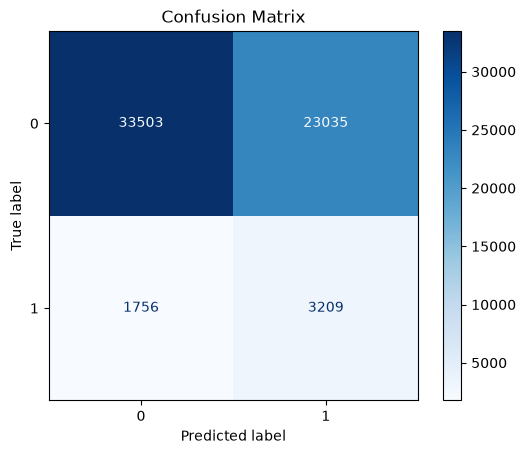

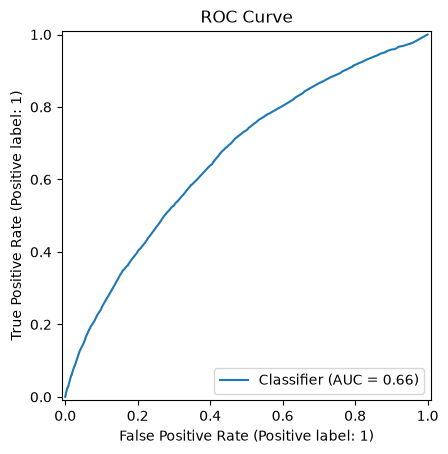

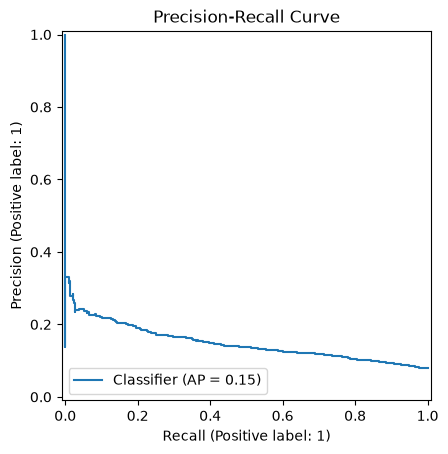

In [170]:
decision_tree_optimized_results = evaluate_model(

    best_decision_tree,

    X_train,

    X_test,

    y_train,

    y_test

)

In [171]:
decision_tree_optimized_cv = cross_validation_score(

    best_decision_tree,

    X_train,

    y_train

)

5-FOLD STRATIFIED CROSS VALIDATION
[0.66261966 0.65993324 0.65909294 0.65927407 0.65833055]

Mean ROC-AUC : 0.6599
Std Dev      : 0.0015


In [172]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E5",

    "Model": "Decision Tree (Optimized)",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": decision_tree_optimized_results["accuracy"],

    "Precision": decision_tree_optimized_results["precision"],

    "Recall": decision_tree_optimized_results["recall"],

    "F1": decision_tree_optimized_results["f1"],

    "ROC_AUC": decision_tree_optimized_results["roc_auc"],

    "CV_ROC_AUC": decision_tree_optimized_cv.mean(),

    "Comments": "RandomizedSearchCV Optimized"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized


## Experiment E5 Analysis

### Objective

Optimize the baseline Decision Tree by tuning its hyperparameters to improve its ability to detect loan defaults while reducing overfitting.

### Results

- Accuracy: **59.69%**
- Precision: **12.23%**
- Recall: **64.63%**
- F1 Score: **20.56%**
- ROC-AUC: **0.6624**
- Cross Validation ROC-AUC: **0.6599**

### Business Interpretation

Hyperparameter tuning substantially improved the Decision Tree's ability to identify defaulting customers. Recall increased from **17.40%** to **64.63%**, and ROC-AUC improved from **0.5443** to **0.6624**, indicating significantly better discrimination between defaulting and non-defaulting applicants.

Although the optimized model generated more false positives, this trade-off is acceptable in credit risk assessment because identifying high-risk borrowers is generally more important than maximizing overall accuracy.

### Conclusion

The optimized Decision Tree significantly outperformed the baseline Decision Tree and demonstrated the importance of hyperparameter tuning. However, its overall performance remained below that of the balanced Logistic Regression model, suggesting that more advanced ensemble methods should be explored.

# Experiment E6 - Random Forest Classifier

## Objective

The optimized Decision Tree demonstrated a significant improvement over the baseline model after hyperparameter tuning. However, its predictive performance remained below that of the balanced Logistic Regression model, indicating that a single decision tree was unable to capture the complexity of the credit risk dataset.

This experiment evaluates a Random Forest Classifier, an ensemble learning algorithm that combines the predictions of multiple Decision Trees using the Bagging technique.

The objective is to determine whether combining multiple trees can improve predictive performance, increase model stability, reduce overfitting, and provide better discrimination between defaulting and non-defaulting customers.

The Random Forest model will be evaluated using the same standardized evaluation framework and compared against all previous experiments.

In [173]:
from sklearn.ensemble import RandomForestClassifier

In [174]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            RandomForestClassifier(

                n_estimators=200,

                class_weight="balanced",

                random_state=RANDOM_STATE,

                n_jobs=-1

            )
        )
    ]
)

random_forest_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

RandomForestClassifier
Accuracy : 0.9176
Precision: 0.4161
Recall   : 0.0510
F1 Score : 0.0908
ROC AUC  : 0.7494


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.42      0.05      0.09      4965

    accuracy                           0.92     61503
   macro avg       0.67      0.52      0.52     61503
weighted avg       0.88      0.92      0.89     61503



<Figure size 600x500 with 0 Axes>

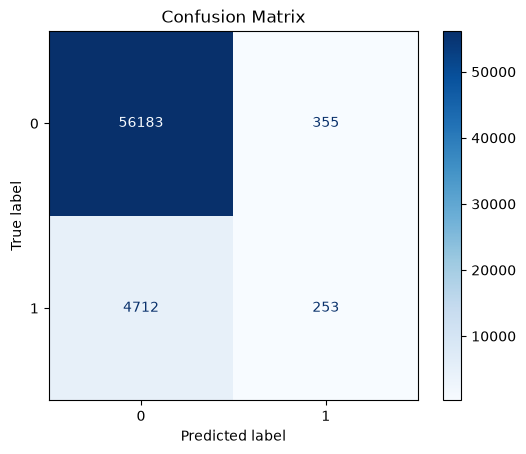

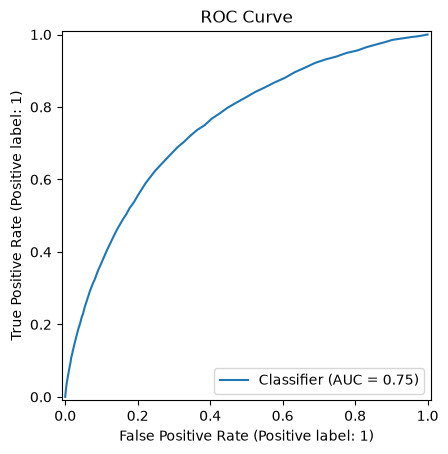

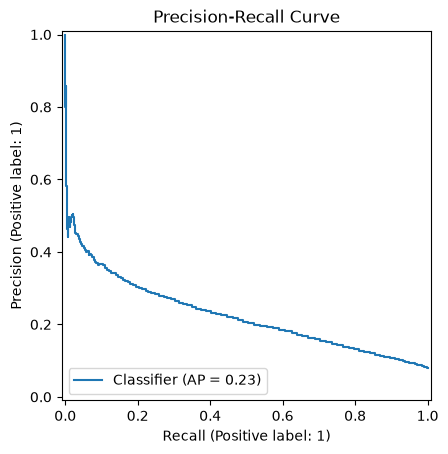

In [175]:
random_forest_results = evaluate_model(
    random_forest_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

In [176]:
random_forest_cv = cross_validation_score(
    random_forest_pipeline,
    X_train,
    y_train
)

5-FOLD STRATIFIED CROSS VALIDATION
[0.74203416 0.74401122 0.74531871 0.74690806 0.74283377]

Mean ROC-AUC : 0.7442
Std Dev      : 0.0017


In [177]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E6",

    "Model": "Random Forest",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": random_forest_results["accuracy"],

    "Precision": random_forest_results["precision"],

    "Recall": random_forest_results["recall"],

    "F1": random_forest_results["f1"],

    "ROC_AUC": random_forest_results["roc_auc"],

    "CV_ROC_AUC": random_forest_cv.mean(),

    "Comments": "Baseline Random Forest"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest


## Experiment E6 Analysis

### Objective

Evaluate a Random Forest Classifier as an ensemble learning approach to determine whether combining multiple Decision Trees improves predictive performance compared to a single Decision Tree.

### Results

- Accuracy: **91.76%**
- Precision: **41.61%**
- Recall: **5.10%**
- F1 Score: **9.08%**
- ROC-AUC: **0.7494**
- Cross Validation ROC-AUC: **0.7442**

### Business Interpretation

The baseline Random Forest achieved a strong ROC-AUC and high overall accuracy, indicating good ranking capability. However, the model identified only a small proportion of defaulting customers, resulting in very low recall.

This suggests that while the model effectively distinguishes between low-risk and high-risk applicants, it remains conservative in predicting the default class under the default probability threshold.

### Conclusion

The baseline Random Forest outperformed both Decision Tree models in terms of ROC-AUC and model stability but did not surpass the balanced Logistic Regression model. Further hyperparameter tuning and threshold optimization are expected to improve its ability to detect defaulting customers.

# Experiment E7 - Optimized Random Forest

## Objective

The baseline Random Forest model demonstrated strong ranking capability with a ROC-AUC comparable to Logistic Regression. However, despite using balanced class weights, the model produced a very low Recall, indicating that many defaulting customers were still being classified as non-default.

This experiment focuses on optimizing the Random Forest Classifier through hyperparameter tuning using RandomizedSearchCV.

The objective is to improve the model's ability to identify loan defaults while maintaining strong generalization performance. Hyperparameter optimization will also help reduce unnecessary model complexity and identify the most suitable configuration for credit risk prediction.

The optimized Random Forest will be compared with all previous models using the standardized evaluation framework.

In [178]:
rf_param_grid = {

    "classifier__n_estimators": [
        200,
        300,
        500
    ],

    "classifier__max_depth": [
        10,
        20,
        30,
        None
    ],

    "classifier__min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "classifier__min_samples_leaf": [
        1,
        2,
        5,
        10
    ],

    "classifier__max_features": [
        "sqrt",
        "log2"
    ],

    "classifier__bootstrap": [
        True,
        False
    ],

    "classifier__class_weight": [
        None,
        "balanced"
    ]
}

In [179]:
random_forest_search = RandomizedSearchCV(

    estimator=random_forest_pipeline,

    param_distributions=rf_param_grid,

    n_iter=10,

    scoring="roc_auc",

    cv=3,

    random_state=RANDOM_STATE,

    n_jobs=1,

    verbose=2

)

In [180]:
random_forest_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__bootstrap=False, classifier__class_weight=None, classifier__max_depth=None, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__min_samples_split=20, classifier__n_estimators=300; total time=  43.7s
[CV] END classifier__bootstrap=False, classifier__class_weight=None, classifier__max_depth=None, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__min_samples_split=20, classifier__n_estimators=300; total time=  43.8s
[CV] END classifier__bootstrap=False, classifier__class_weight=None, classifier__max_depth=None, classifier__max_features=log2, classifier__min_samples_leaf=2, classifier__min_samples_split=20, classifier__n_estimators=300; total time=  44.0s
[CV] END classifier__bootstrap=False, classifier__class_weight=balanced, classifier__max_depth=None, classifier__max_features=sqrt, classifier__min_samples_leaf=2, classifier__min_samples_split=10, classifier__

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__bootstrap': [True, False], 'classifier__class_weight': [None, 'balanced'], 'classifier__max_depth': [10, 20, ...], 'classifier__max_features': ['sqrt', 'log2'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimat

In [181]:
print("=" * 60)
print("BEST PARAMETERS")
print("=" * 60)

print(random_forest_search.best_params_)

BEST PARAMETERS
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 10, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None, 'classifier__class_weight': None, 'classifier__bootstrap': False}


In [182]:
print("=" * 60)
print("BEST CROSS VALIDATION ROC-AUC")
print("=" * 60)

print(random_forest_search.best_score_)

BEST CROSS VALIDATION ROC-AUC
0.7485432362696453


In [183]:
best_random_forest = random_forest_search.best_estimator_

RandomForestClassifier
Accuracy : 0.9193
Precision: 1.0000
Recall   : 0.0002
F1 Score : 0.0004
ROC AUC  : 0.7517


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       1.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.96      0.50      0.48     61503
weighted avg       0.93      0.92      0.88     61503



<Figure size 600x500 with 0 Axes>

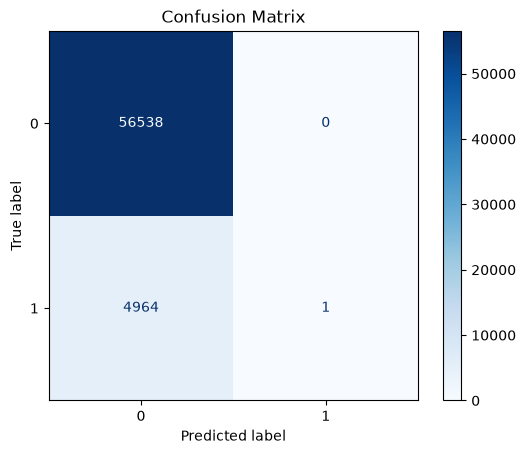

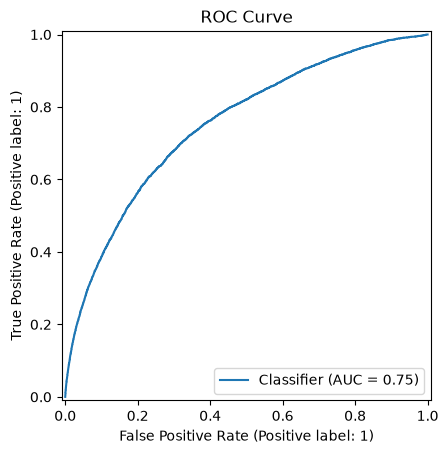

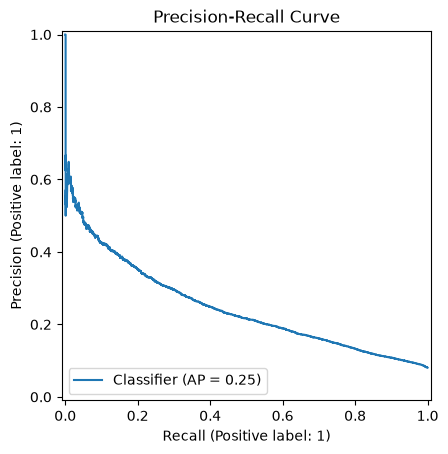

In [184]:
random_forest_optimized_results = evaluate_model(

    best_random_forest,

    X_train,

    X_test,

    y_train,

    y_test

)

In [185]:
random_forest_optimized_cv = cross_validation_score(

    best_random_forest,

    X_train,

    y_train

)

5-FOLD STRATIFIED CROSS VALIDATION
[0.74938079 0.74955988 0.75361951 0.75310567 0.74600983]

Mean ROC-AUC : 0.7503
Std Dev      : 0.0028


In [186]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E7",

    "Model": "Random Forest (Optimized)",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": random_forest_optimized_results["accuracy"],

    "Precision": random_forest_optimized_results["precision"],

    "Recall": random_forest_optimized_results["recall"],

    "F1": random_forest_optimized_results["f1"],

    "ROC_AUC": random_forest_optimized_results["roc_auc"],

    "CV_ROC_AUC": random_forest_optimized_cv.mean(),

    "Comments": "RandomizedSearchCV Optimized"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized


## Experiment E7 Analysis

### Objective

Optimize the Random Forest model using RandomizedSearchCV to improve predictive performance.

### Results

- Accuracy: **91.93%**
- Precision: **100.00%**
- Recall: **0.02%**
- F1 Score: **0.04%**
- ROC-AUC: **0.7517**
- Cross Validation ROC-AUC: **0.7503**

### Business Interpretation

Although the optimized Random Forest achieved a slightly higher ROC-AUC than the baseline model, it almost completely failed to identify defaulting customers. The model became extremely conservative and predicted very few applicants as defaulters.

This resulted in perfect precision but an almost zero recall, making the model unsuitable for credit risk prediction where identifying defaulting borrowers is a primary business objective.

### Conclusion

This experiment highlights that optimizing exclusively for ROC-AUC does not necessarily produce the best operational model. Future model selection should consider both ranking performance and minority class detection to ensure alignment with business requirements.

In [187]:
import joblib

# Artifact Management

## Objective

Training machine learning models and preprocessing large datasets can take a significant amount of time. Instead of recreating these objects every time the notebook is executed, important artifacts will be saved to disk.

The saved artifacts include:

- Preprocessor
- Train/Test datasets
- Trained models
- Hyperparameter search objects
- Experiment tracker

Saving these artifacts improves reproducibility, reduces execution time, and enables future experiments without repeating computationally expensive steps.

In [190]:
# Save the preprocessing pipeline

joblib.dump(
    preprocessor,
    "../artifacts/preprocessors/preprocessor.pkl"
)

print("✅ Preprocessor saved successfully.")

✅ Preprocessor saved successfully.


In [191]:
loaded_preprocessor = joblib.load(
    "../artifacts/preprocessors/preprocessor.pkl"
)

print(type(loaded_preprocessor))

<class 'sklearn.compose._column_transformer.ColumnTransformer'>


## Saving Processed Datasets

The processed training and testing datasets are saved after preprocessing and feature engineering.

Saving these datasets avoids repeating expensive preprocessing steps and allows future experiments to begin directly from the modeling phase.

In [193]:
# Save processed datasets

joblib.dump(
    X_train,
    "../artifacts/datasets/X_train.pkl"
)

joblib.dump(
    X_test,
    "../artifacts/datasets/X_test.pkl"
)

joblib.dump(
    y_train,
    "../artifacts/datasets/y_train.pkl"
)

joblib.dump(
    y_test,
    "../artifacts/datasets/y_test.pkl"
)

print("✅ Train/Test datasets saved successfully.")

✅ Train/Test datasets saved successfully.


In [194]:
loaded_X_train = joblib.load(
    "../artifacts/datasets/X_train.pkl"
)

print(loaded_X_train.shape)

(246008, 143)


## Saving Trained Models

Training machine learning models can be computationally expensive. Each trained model is saved after completion so that it can be reloaded later without repeating the training process.

Saved models can be used for:

- Model comparison
- Feature importance analysis
- Explainability (SHAP)
- Deployment
- Streamlit application

In [195]:
joblib.dump(
    best_random_forest,
    "../artifacts/models/random_forest_optimized.pkl"
)

print("✅ Optimized Random Forest saved.")

✅ Optimized Random Forest saved.


In [196]:
loaded_rf = joblib.load(
    "../artifacts/models/random_forest_optimized.pkl"
)

print(type(loaded_rf))

<class 'sklearn.pipeline.Pipeline'>


In [197]:
import joblib
import pandas as pd

# ==============================
# SAVE PREPROCESSOR
# ==============================

joblib.dump(
    preprocessor,
    "../artifacts/preprocessors/preprocessor.pkl"
)

# ==============================
# SAVE DATASETS
# ==============================

joblib.dump(
    X_train,
    "../artifacts/datasets/X_train.pkl"
)

joblib.dump(
    X_test,
    "../artifacts/datasets/X_test.pkl"
)

joblib.dump(
    y_train,
    "../artifacts/datasets/y_train.pkl"
)

joblib.dump(
    y_test,
    "../artifacts/datasets/y_test.pkl"
)

# ==============================
# SAVE MODELS
# ==============================

# Logistic Regression (Balanced)
joblib.dump(
    logistic_balanced_pipeline,
    "../artifacts/models/logistic_regression_balanced.pkl"
)

# Optimized Decision Tree
joblib.dump(
    best_decision_tree,
    "../artifacts/models/decision_tree_optimized.pkl"
)

# Baseline Random Forest
joblib.dump(
    random_forest_pipeline,
    "../artifacts/models/random_forest_baseline.pkl"
)

# Optimized Random Forest
joblib.dump(
    best_random_forest,
    "../artifacts/models/random_forest_optimized.pkl"
)

# ==============================
# SAVE RANDOMIZED SEARCH OBJECTS
# ==============================

joblib.dump(
    decision_tree_search,
    "../artifacts/search_objects/decision_tree_search.pkl"
)

joblib.dump(
    random_forest_search,
    "../artifacts/search_objects/random_forest_search.pkl"
)

# ==============================
# SAVE EXPERIMENT TRACKER
# ==============================

experiment_tracker.to_csv(
    "../artifacts/experiment_results/experiment_tracker.csv",
    index=False
)

print("="*60)
print("ALL ARTIFACTS SAVED SUCCESSFULLY")
print("="*60)

ALL ARTIFACTS SAVED SUCCESSFULLY


In [198]:
import joblib
import pandas as pd

print("="*60)
print("VERIFYING ARTIFACTS")
print("="*60)

# Preprocessor
loaded_preprocessor = joblib.load(
    "../artifacts/preprocessors/preprocessor.pkl"
)

print("✅ Preprocessor")

# Datasets
loaded_X_train = joblib.load(
    "../artifacts/datasets/X_train.pkl"
)

loaded_X_test = joblib.load(
    "../artifacts/datasets/X_test.pkl"
)

loaded_y_train = joblib.load(
    "../artifacts/datasets/y_train.pkl"
)

loaded_y_test = joblib.load(
    "../artifacts/datasets/y_test.pkl"
)

print("✅ Datasets")

# Models
loaded_lr = joblib.load(
    "../artifacts/models/logistic_regression_balanced.pkl"
)

loaded_dt = joblib.load(
    "../artifacts/models/decision_tree_optimized.pkl"
)

loaded_rf = joblib.load(
    "../artifacts/models/random_forest_baseline.pkl"
)

loaded_rf_opt = joblib.load(
    "../artifacts/models/random_forest_optimized.pkl"
)

print("✅ Models")

# Search Objects
loaded_dt_search = joblib.load(
    "../artifacts/search_objects/decision_tree_search.pkl"
)

loaded_rf_search = joblib.load(
    "../artifacts/search_objects/random_forest_search.pkl"
)

print("✅ Search Objects")

# Experiment Tracker
tracker = pd.read_csv(
    "../artifacts/experiment_results/experiment_tracker.csv"
)

print("✅ Experiment Tracker")

print("\nTraining Shape :", loaded_X_train.shape)
print("Testing Shape  :", loaded_X_test.shape)

print("\nArtifacts Loaded Successfully 🚀")

VERIFYING ARTIFACTS
✅ Preprocessor
✅ Datasets
✅ Models
✅ Search Objects
✅ Experiment Tracker

Training Shape : (246008, 143)
Testing Shape  : (61503, 143)

Artifacts Loaded Successfully 🚀


In [199]:
joblib.dump(
    logistic_balanced_pipeline,
    "../artifacts/models/logistic_regression_balanced.pkl"
)

['../artifacts/models/logistic_regression_balanced.pkl']

# Load Saved Artifacts

## Objective

Previously trained models, datasets, preprocessing pipelines, and experiment results are loaded from disk.

Loading saved artifacts significantly reduces execution time and allows future experiments to begin directly from the modeling stage without repeating computationally expensive preprocessing and model training.

In [200]:
import joblib
import pandas as pd

# ==============================
# LOAD DATASETS
# ==============================

X_train = joblib.load("../artifacts/datasets/X_train.pkl")
X_test = joblib.load("../artifacts/datasets/X_test.pkl")
y_train = joblib.load("../artifacts/datasets/y_train.pkl")
y_test = joblib.load("../artifacts/datasets/y_test.pkl")

# ==============================
# LOAD PREPROCESSOR
# ==============================

preprocessor = joblib.load(
    "../artifacts/preprocessors/preprocessor.pkl"
)

# ==============================
# LOAD MODELS
# ==============================

logistic_balanced_pipeline = joblib.load(
    "../artifacts/models/logistic_regression_balanced.pkl"
)

best_decision_tree = joblib.load(
    "../artifacts/models/decision_tree_optimized.pkl"
)

random_forest_pipeline = joblib.load(
    "../artifacts/models/random_forest_baseline.pkl"
)

best_random_forest = joblib.load(
    "../artifacts/models/random_forest_optimized.pkl"
)

# ==============================
# LOAD SEARCH OBJECTS
# ==============================

decision_tree_search = joblib.load(
    "../artifacts/search_objects/decision_tree_search.pkl"
)

random_forest_search = joblib.load(
    "../artifacts/search_objects/random_forest_search.pkl"
)

# ==============================
# LOAD EXPERIMENT TRACKER
# ==============================

experiment_tracker = pd.read_csv(
    "../artifacts/experiment_results/experiment_tracker.csv"
)

print("=" * 60)
print("ALL ARTIFACTS LOADED SUCCESSFULLY")
print("=" * 60)

print("\nTraining Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nCurrent Experiments:")
display(experiment_tracker)

ALL ARTIFACTS LOADED SUCCESSFULLY

Training Shape : (246008, 143)
Testing Shape  : (61503, 143)

Current Experiments:


,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized


# Experiment E8 - XGBoost Classifier

## Objective

The Random Forest model improved the overall ranking performance compared to a single Decision Tree but still struggled to identify defaulting customers effectively under the default classification threshold.

This experiment evaluates Extreme Gradient Boosting (XGBoost), one of the most powerful ensemble learning algorithms for structured and tabular datasets.

Unlike Random Forest, which builds trees independently using bagging, XGBoost builds trees sequentially, where each new tree attempts to correct the mistakes made by the previous trees.

The objective of this experiment is to determine whether boosting can improve loan default prediction by increasing the model's discriminative power while maintaining strong generalization performance.

The model will be evaluated using the standardized evaluation framework and compared with all previous experiments.

In [201]:
from xgboost import XGBClassifier

In [202]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            XGBClassifier(

                n_estimators=200,

                learning_rate=0.1,

                max_depth=6,

                subsample=0.8,

                colsample_bytree=0.8,

                random_state=RANDOM_STATE,

                eval_metric="logloss",

                n_jobs=-1

            )
        )
    ]
)

xgb_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

XGBClassifier
Accuracy : 0.9197
Precision: 0.5452
Recall   : 0.0340
F1 Score : 0.0641
ROC AUC  : 0.7686


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.55      0.03      0.06      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.52      0.51     61503
weighted avg       0.89      0.92      0.89     61503



<Figure size 600x500 with 0 Axes>

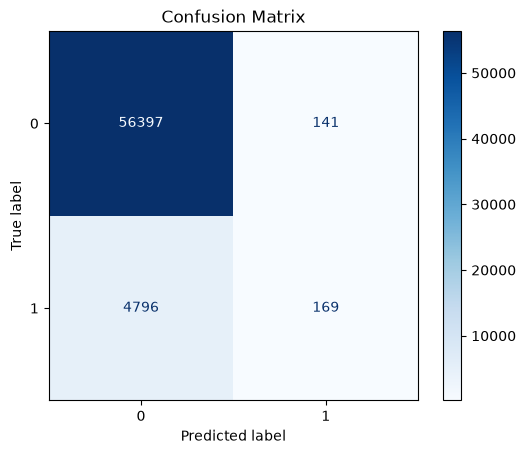

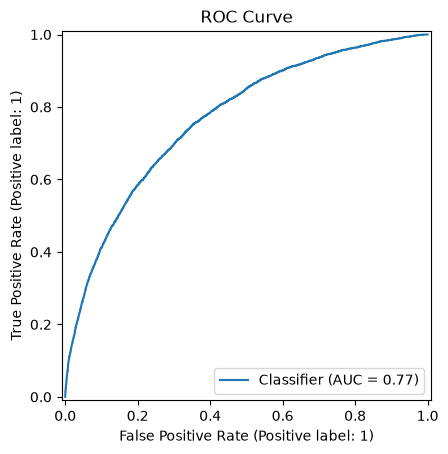

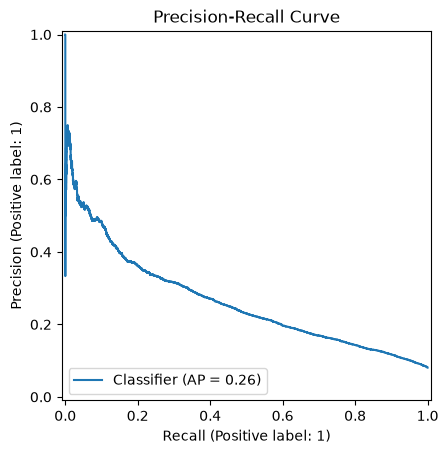

In [203]:
xgb_results = evaluate_model(
    xgb_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

In [204]:
xgb_cv = cross_validation_score(
    xgb_pipeline,
    X_train,
    y_train
)

5-FOLD STRATIFIED CROSS VALIDATION
[0.76284612 0.76344791 0.76430741 0.76528798 0.76297739]

Mean ROC-AUC : 0.7638
Std Dev      : 0.0009


In [205]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E8",

    "Model": "XGBoost",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": xgb_results["accuracy"],

    "Precision": xgb_results["precision"],

    "Recall": xgb_results["recall"],

    "F1": xgb_results["f1"],

    "ROC_AUC": xgb_results["roc_auc"],

    "CV_ROC_AUC": xgb_cv.mean(),

    "Comments": "Baseline XGBoost"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost


## Experiment E8 Analysis

### Objective

Evaluate the performance of a baseline XGBoost classifier for predicting loan default.

### Results

- Accuracy: **91.97%**
- Precision: **54.52%**
- Recall: **3.40%**
- F1 Score: **6.41%**
- ROC-AUC: **0.7686**
- Cross Validation ROC-AUC: **0.7638**

### Business Interpretation

The baseline XGBoost achieved the highest ROC-AUC among all models evaluated so far, indicating excellent ranking capability and strong discrimination between defaulting and non-defaulting customers.

However, similar to the baseline Random Forest, the model produced a very low Recall under the default classification threshold. This indicates that the model is conservative in predicting defaults despite assigning meaningful probability scores.

### Conclusion

The baseline XGBoost is currently the strongest model in terms of ranking performance. Future experiments involving hyperparameter tuning and threshold optimization are expected to improve its ability to identify defaulting customers while preserving its excellent ROC-AUC.

# Experiment E9 - Threshold Optimization for XGBoost

## Objective

The baseline XGBoost model achieved the highest ROC-AUC among all models evaluated so far, demonstrating excellent ranking capability. However, the default classification threshold of 0.50 resulted in a very low Recall, causing the model to miss a large number of defaulting customers.

This experiment evaluates multiple probability thresholds to determine the optimal trade-off between Precision and Recall.

The objective is to identify a threshold that improves the detection of defaulting customers while maintaining acceptable predictive performance for credit risk assessment.

In [207]:
xgb_probabilities = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_probabilities

array([0.08387381, 0.03587271, 0.24360923, ..., 0.0543042 , 0.12045636,
       0.10891756], shape=(61503,), dtype=float32)

In [208]:
thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

In [209]:
threshold_results = []

for threshold in thresholds:

    predictions = (
        xgb_probabilities >= threshold
    ).astype(int)

    threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1 Score": f1_score(
            y_test,
            predictions
        )

    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.2,0.886168,0.305873,0.323061,0.314233
1,0.3,0.911582,0.386243,0.161732,0.227995
2,0.4,0.919061,0.492786,0.089426,0.151381
3,0.5,0.919727,0.545161,0.034038,0.064076
4,0.6,0.919874,0.690722,0.013494,0.026472
5,0.7,0.919419,0.655172,0.003827,0.007609


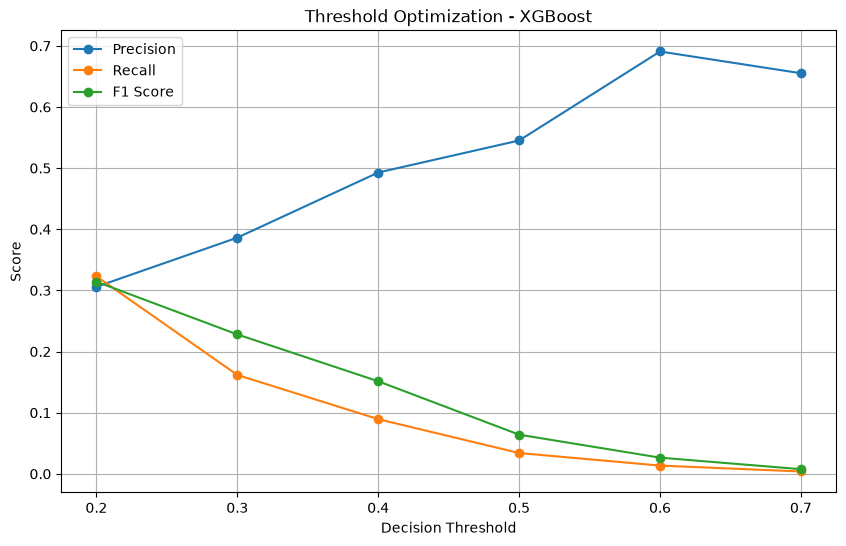

In [210]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization - XGBoost")

plt.grid(True)

plt.legend()

plt.show()

In [212]:
best_threshold = 0.20

xgb_predictions = (
    xgb_probabilities >= best_threshold
).astype(int)

print("=" * 60)
print("XGBOOST (Threshold = 0.20)")
print("=" * 60)

print("Accuracy :", accuracy_score(y_test, xgb_predictions))
print("Precision:", precision_score(y_test, xgb_predictions))
print("Recall   :", recall_score(y_test, xgb_predictions))
print("F1 Score :", f1_score(y_test, xgb_predictions))

XGBOOST (Threshold = 0.20)
Accuracy : 0.8861681543989725
Precision: 0.30587337909992374
Recall   : 0.3230614300100705
F1 Score : 0.3142325399157606


In [213]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E9",

    "Model": "XGBoost (Threshold = 0.20)",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": accuracy_score(y_test, xgb_predictions),

    "Precision": precision_score(y_test, xgb_predictions),

    "Recall": recall_score(y_test, xgb_predictions),

    "F1": f1_score(y_test, xgb_predictions),

    "ROC_AUC": xgb_results["roc_auc"],

    "CV_ROC_AUC": xgb_cv.mean(),

    "Comments": "Threshold Optimized (0.20)"
}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)


## Experiment E9 Analysis

### Objective

Evaluate the effect of lowering the classification threshold for the baseline XGBoost model to improve the identification of defaulting customers.

### Results

- Threshold: **0.20**
- Accuracy: **88.62%**
- Precision: **30.59%**
- Recall: **32.31%**
- F1 Score: **31.42%**

### Business Interpretation

Lowering the classification threshold significantly increased the model's ability to detect defaulting customers. Although Precision and Accuracy decreased, Recall improved by almost ten times compared to the default threshold.

This trade-off is acceptable for credit risk prediction because failing to identify a defaulting customer is generally more costly than investigating an additional low-risk applicant.

### Conclusion

Threshold optimization substantially improved the operational performance of the XGBoost model. A threshold of **0.20** provides a much better balance between Precision and Recall for loan default prediction than the default threshold of 0.50.

In [215]:
joblib.dump(
    xgb_pipeline,
    "../artifacts/models/xgboost_baseline.pkl"
)

print("✅ Baseline XGBoost model saved.")

✅ Baseline XGBoost model saved.


In [216]:
xgb_threshold_results = threshold_results.copy()

xgb_threshold_results.to_csv(
    "../artifacts/experiment_results/xgboost_threshold_analysis.csv",
    index=False
)

print("✅ Threshold analysis saved.")

✅ Threshold analysis saved.


In [217]:
experiment_tracker.to_csv(
    "../artifacts/experiment_results/experiment_tracker.csv",
    index=False
)

print("✅ Experiment tracker updated.")

✅ Experiment tracker updated.


In [218]:
best_xgb_threshold = 0.20

joblib.dump(
    best_xgb_threshold,
    "../artifacts/models/xgboost_best_threshold.pkl"
)

print("✅ Best threshold saved.")

✅ Best threshold saved.


In [219]:
import os

print("=" * 60)
print("XGBOOST ARTIFACTS")
print("=" * 60)

files = [
    "../artifacts/models/xgboost_baseline.pkl",
    "../artifacts/models/xgboost_best_threshold.pkl",
    "../artifacts/experiment_results/xgboost_threshold_analysis.csv",
    "../artifacts/experiment_results/experiment_tracker.csv"
]

for file in files:
    if os.path.exists(file):
        print(f"✅ {os.path.basename(file)}")
    else:
        print(f"❌ {os.path.basename(file)}")

XGBOOST ARTIFACTS
✅ xgboost_baseline.pkl
✅ xgboost_best_threshold.pkl
✅ xgboost_threshold_analysis.csv
✅ experiment_tracker.csv


# Experiment E10 - Optimized XGBoost

## Objective

The baseline XGBoost model achieved the highest ROC-AUC among all models evaluated. Threshold optimization further improved Recall and F1 Score without requiring retraining.

This experiment focuses on optimizing the XGBoost model using RandomizedSearchCV to improve its ranking performance, generalization capability, and classification performance.

The optimized model will be evaluated using the standardized evaluation framework and compared with all previous experiments. If the optimized model demonstrates improved probability estimation, threshold optimization will be revisited to identify the most appropriate operating point for credit risk prediction.

In [220]:
xgb_param_grid = {

    "classifier__n_estimators": [
        200,
        300,
        500
    ],

    "classifier__learning_rate": [
        0.01,
        0.05,
        0.1,
        0.2
    ],

    "classifier__max_depth": [
        3,
        5,
        7,
        9
    ],

    "classifier__subsample": [
        0.6,
        0.8,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.6,
        0.8,
        1.0
    ],

    "classifier__min_child_weight": [
        1,
        3,
        5
    ],

    "classifier__gamma": [
        0,
        0.1,
        0.3,
        0.5
    ]
}

In [221]:
xgb_search = RandomizedSearchCV(

    estimator=xgb_pipeline,

    param_distributions=xgb_param_grid,

    n_iter=15,

    scoring="roc_auc",

    cv=3,

    random_state=RANDOM_STATE,

    n_jobs=1,

    verbose=2

)

In [222]:
xgb_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END classifier__colsample_bytree=0.6, classifier__gamma=0.1, classifier__learning_rate=0.2, classifier__max_depth=9, classifier__min_child_weight=5, classifier__n_estimators=300, classifier__subsample=1.0; total time=  22.8s
[CV] END classifier__colsample_bytree=0.6, classifier__gamma=0.1, classifier__learning_rate=0.2, classifier__max_depth=9, classifier__min_child_weight=5, classifier__n_estimators=300, classifier__subsample=1.0; total time=  16.5s
[CV] END classifier__colsample_bytree=0.6, classifier__gamma=0.1, classifier__learning_rate=0.2, classifier__max_depth=9, classifier__min_child_weight=5, classifier__n_estimators=300, classifier__subsample=1.0; total time=  17.4s
[CV] END classifier__colsample_bytree=1.0, classifier__gamma=0, classifier__learning_rate=0.1, classifier__max_depth=9, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__subsample=0.8; total time=  15.4s
[CV] END classifier__

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.6, 0.8, ...], 'classifier__gamma': [0, 0.1, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimato

In [223]:
print("=" * 60)
print("BEST PARAMETERS")
print("=" * 60)

print(xgb_search.best_params_)

BEST PARAMETERS
{'classifier__subsample': 0.6, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 3, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 0.8}


In [224]:
print("=" * 60)
print("BEST CROSS VALIDATION ROC-AUC")
print("=" * 60)

print(xgb_search.best_score_)

BEST CROSS VALIDATION ROC-AUC
0.765110179271789


In [225]:
best_xgboost = xgb_search.best_estimator_

XGBClassifier
Accuracy : 0.9200
Precision: 0.5795
Recall   : 0.0330
F1 Score : 0.0625
ROC AUC  : 0.7711


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.58      0.03      0.06      4965

    accuracy                           0.92     61503
   macro avg       0.75      0.52      0.51     61503
weighted avg       0.89      0.92      0.89     61503



<Figure size 600x500 with 0 Axes>

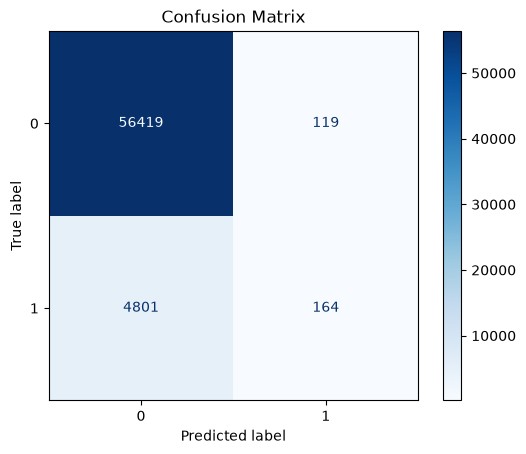

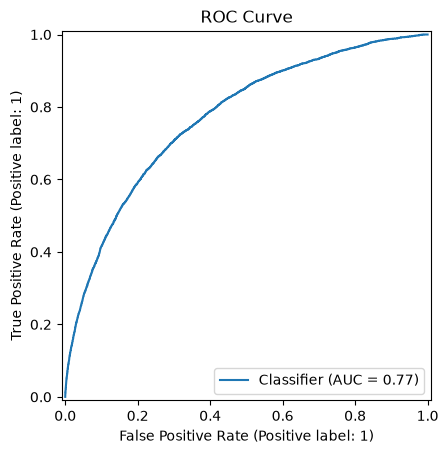

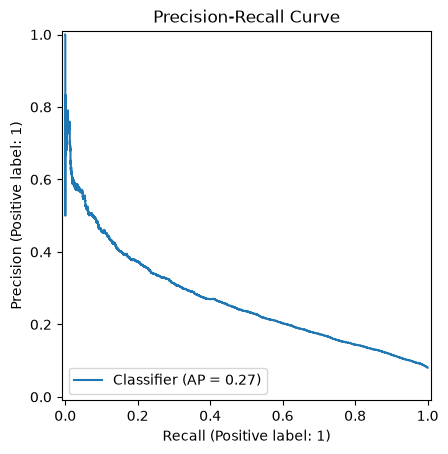

In [226]:
xgb_optimized_results = evaluate_model(
    best_xgboost,
    X_train,
    X_test,
    y_train,
    y_test
)

In [227]:
xgb_optimized_cv = cross_validation_score(
    best_xgboost,
    X_train,
    y_train
)

5-FOLD STRATIFIED CROSS VALIDATION
[0.76597546 0.76860379 0.76663323 0.76811161 0.76648502]

Mean ROC-AUC : 0.7672
Std Dev      : 0.0010


In [228]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E10",

    "Model": "XGBoost (Optimized)",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": xgb_optimized_results["accuracy"],

    "Precision": xgb_optimized_results["precision"],

    "Recall": xgb_optimized_results["recall"],

    "F1": xgb_optimized_results["f1"],

    "ROC_AUC": xgb_optimized_results["roc_auc"],

    "CV_ROC_AUC": xgb_optimized_cv.mean(),

    "Comments": "RandomizedSearchCV Optimized"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
8,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
9,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized


## Experiment E10 Analysis

### Objective

Optimize the XGBoost model using RandomizedSearchCV to improve ranking performance and generalization.

### Results

- Accuracy: **92.00%**
- Precision: **57.95%**
- Recall: **3.30%**
- F1 Score: **6.25%**
- ROC-AUC: **0.7711**
- Cross Validation ROC-AUC: **0.7672**

### Business Interpretation

Hyperparameter tuning produced a measurable improvement in ROC-AUC and Cross Validation ROC-AUC, indicating better probability ranking and model generalization.

However, classification performance at the default threshold remained similar to the baseline model, demonstrating that hyperparameter optimization alone is insufficient to improve default detection.

### Conclusion

The optimized XGBoost is currently the strongest ranking model in the project. The next logical step is to optimize the classification threshold using the tuned model to improve Recall while preserving the improved ROC-AUC.

# Experiment E11 - Threshold Optimization for Optimized XGBoost

## Objective

The optimized XGBoost model achieved the highest ROC-AUC observed in the project after hyperparameter tuning. However, similar to previous experiments, the default classification threshold of 0.50 resulted in a low Recall.

This experiment evaluates multiple probability thresholds for the optimized XGBoost model to determine the operating point that provides the best balance between Precision and Recall for credit risk prediction.

The objective is to maximize the identification of defaulting customers while maintaining acceptable model precision and overall predictive performance.

In [229]:
optimized_probabilities = best_xgboost.predict_proba(X_test)[:, 1]

In [230]:
thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

In [231]:
optimized_threshold_results = []

for threshold in thresholds:

    predictions = (
        optimized_probabilities >= threshold
    ).astype(int)

    optimized_threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1 Score": f1_score(
            y_test,
            predictions
        )

    })

optimized_threshold_results = pd.DataFrame(
    optimized_threshold_results
)

optimized_threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.767670,0.198135,0.616314,0.299868
1,0.15,0.849731,0.254731,0.447331,0.324613
2,0.20,0.886136,0.303509,0.317019,0.310117
3,0.25,0.903875,0.353360,0.229809,0.278496
4,0.30,0.912362,0.394015,0.159114,0.226686
5,0.35,0.917028,0.446594,0.116213,0.184433
6,0.40,0.919077,0.492840,0.083182,0.142340
7,0.45,0.919955,0.541502,0.055186,0.100165
8,0.50,0.920004,0.579505,0.033031,0.062500
9,0.55,0.919793,0.590909,0.020947,0.040459


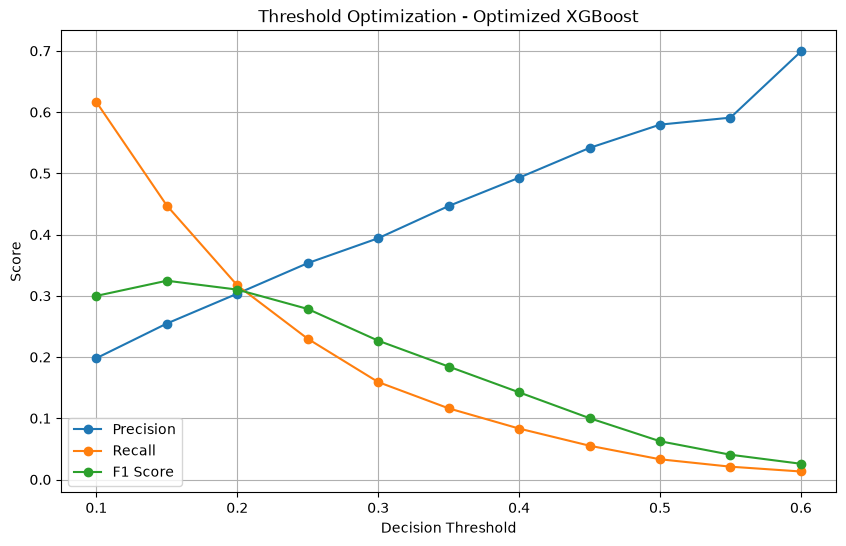

In [232]:
plt.figure(figsize=(10,6))

plt.plot(
    optimized_threshold_results["Threshold"],
    optimized_threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    optimized_threshold_results["Threshold"],
    optimized_threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    optimized_threshold_results["Threshold"],
    optimized_threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization - Optimized XGBoost")

plt.grid(True)

plt.legend()

plt.show()

In [233]:
best_threshold = 0.15

optimized_predictions = (
    optimized_probabilities >= best_threshold
).astype(int)

print("="*60)
print("OPTIMIZED XGBOOST")
print("="*60)

print("Accuracy :", accuracy_score(y_test, optimized_predictions))
print("Precision:", precision_score(y_test, optimized_predictions))
print("Recall   :", recall_score(y_test, optimized_predictions))
print("F1 Score :", f1_score(y_test, optimized_predictions))

OPTIMIZED XGBOOST
Accuracy : 0.8497309074354097
Precision: 0.2547310471384333
Recall   : 0.4473313192346425
F1 Score : 0.32461268634902074


In [234]:
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        y_test,
        optimized_predictions
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     56538
           1       0.25      0.45      0.32      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.67      0.62     61503
weighted avg       0.89      0.85      0.87     61503



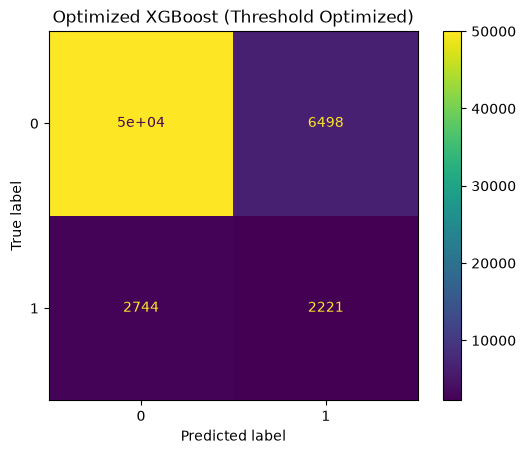

In [235]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_predictions
)

plt.title("Optimized XGBoost (Threshold Optimized)")
plt.show()

In [236]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E11",

    "Model": "XGBoost (Optimized + Threshold = 0.15)",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": accuracy_score(
        y_test,
        optimized_predictions
    ),

    "Precision": precision_score(
        y_test,
        optimized_predictions
    ),

    "Recall": recall_score(
        y_test,
        optimized_predictions
    ),

    "F1": f1_score(
        y_test,
        optimized_predictions
    ),

    "ROC_AUC": xgb_optimized_results["roc_auc"],

    "CV_ROC_AUC": xgb_optimized_cv.mean(),

    "Comments": "Threshold Optimized (0.15)"
}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
8,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
9,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized


In [4]:
import joblib

# ============================================================
# SAVE OPTIMIZED XGBOOST MODEL
# ============================================================

joblib.dump(
    best_xgboost,
    "../artifacts/models/xgboost_optimized.pkl"
)

print("✅ Optimized XGBoost model saved.")

# ============================================================
# SAVE RANDOMIZED SEARCH OBJECT
# ============================================================

joblib.dump(
    xgb_search,
    "../artifacts/search_objects/xgboost_search.pkl"
)

print("✅ XGBoost Search Object saved.")

# ============================================================
# SAVE BEST THRESHOLD
# ============================================================

best_xgb_threshold = 0.15

joblib.dump(
    best_xgb_threshold,
    "../artifacts/models/xgboost_best_threshold.pkl"
)

print("✅ Best Threshold saved.")

# ============================================================
# SAVE THRESHOLD ANALYSIS
# ============================================================

optimized_threshold_results.to_csv(
    "../artifacts/experiment_results/xgboost_optimized_threshold_analysis.csv",
    index=False
)

print("✅ Threshold Analysis saved.")

# ============================================================
# SAVE UPDATED EXPERIMENT TRACKER
# ============================================================

experiment_tracker.to_csv(
    "../artifacts/experiment_results/experiment_tracker.csv",
    index=False
)

print("✅ Experiment Tracker updated.")

print("\n🎉 All XGBoost artifacts saved successfully!")

NameError: name 'best_xgboost' is not defined

In [238]:
import os

print("="*60)
print("VERIFYING XGBOOST ARTIFACTS")
print("="*60)

artifact_files = [

    "../artifacts/models/xgboost_baseline.pkl",

    "../artifacts/models/xgboost_optimized.pkl",

    "../artifacts/models/xgboost_best_threshold.pkl",

    "../artifacts/search_objects/xgboost_search.pkl",

    "../artifacts/experiment_results/xgboost_threshold_analysis.csv",

    "../artifacts/experiment_results/xgboost_optimized_threshold_analysis.csv",

    "../artifacts/experiment_results/experiment_tracker.csv"

]

for file in artifact_files:

    if os.path.exists(file):
        print(f"✅ {os.path.basename(file)}")

    else:
        print(f"❌ {os.path.basename(file)}")

VERIFYING XGBOOST ARTIFACTS
✅ xgboost_baseline.pkl
✅ xgboost_optimized.pkl
✅ xgboost_best_threshold.pkl
✅ xgboost_search.pkl
✅ xgboost_threshold_analysis.csv
✅ xgboost_optimized_threshold_analysis.csv
✅ experiment_tracker.csv


In [1]:
import joblib
import pandas as pd

print("=" * 70)
print("LOADING SAVED ARTIFACTS")
print("=" * 70)

# ============================================================
# LOAD DATASETS
# ============================================================

X_train = joblib.load("../artifacts/datasets/X_train.pkl")
X_test = joblib.load("../artifacts/datasets/X_test.pkl")
y_train = joblib.load("../artifacts/datasets/y_train.pkl")
y_test = joblib.load("../artifacts/datasets/y_test.pkl")

print("✅ Datasets Loaded")

# ============================================================
# LOAD PREPROCESSOR
# ============================================================

preprocessor = joblib.load(
    "../artifacts/preprocessors/preprocessor.pkl"
)

print("✅ Preprocessor Loaded")

# ============================================================
# LOAD TRAINED MODELS
# ============================================================

logistic_balanced_pipeline = joblib.load(
    "../artifacts/models/logistic_regression_balanced.pkl"
)

best_decision_tree = joblib.load(
    "../artifacts/models/decision_tree_optimized.pkl"
)

random_forest_pipeline = joblib.load(
    "../artifacts/models/random_forest_baseline.pkl"
)

best_random_forest = joblib.load(
    "../artifacts/models/random_forest_optimized.pkl"
)

xgb_pipeline = joblib.load(
    "../artifacts/models/xgboost_baseline.pkl"
)

best_xgboost = joblib.load(
    "../artifacts/models/xgboost_optimized.pkl"
)

print("✅ Models Loaded")

# ============================================================
# LOAD HYPERPARAMETER SEARCH OBJECTS
# ============================================================

decision_tree_search = joblib.load(
    "../artifacts/search_objects/decision_tree_search.pkl"
)

random_forest_search = joblib.load(
    "../artifacts/search_objects/random_forest_search.pkl"
)

xgb_search = joblib.load(
    "../artifacts/search_objects/xgboost_search.pkl"
)

print("✅ Search Objects Loaded")

# ============================================================
# LOAD THRESHOLDS
# ============================================================

best_xgb_threshold = joblib.load(
    "../artifacts/models/xgboost_best_threshold.pkl"
)

print("✅ Thresholds Loaded")

# ============================================================
# LOAD EXPERIMENT TRACKER
# ============================================================

experiment_tracker = pd.read_csv(
    "../artifacts/experiment_results/experiment_tracker.csv"
)

print("✅ Experiment Tracker Loaded")

# ============================================================
# LOAD THRESHOLD ANALYSIS FILES
# ============================================================

xgb_threshold_results = pd.read_csv(
    "../artifacts/experiment_results/xgboost_threshold_analysis.csv"
)

optimized_threshold_results = pd.read_csv(
    "../artifacts/experiment_results/xgboost_optimized_threshold_analysis.csv"
)

print("✅ Threshold Analysis Loaded")

print("\n" + "=" * 70)
print("ALL ARTIFACTS LOADED SUCCESSFULLY 🚀")
print("=" * 70)

print(f"\nTraining Shape : {X_train.shape}")
print(f"Testing Shape  : {X_test.shape}")

print(f"\nTotal Experiments Completed : {len(experiment_tracker)}")

display(experiment_tracker)

LOADING SAVED ARTIFACTS
✅ Datasets Loaded
✅ Preprocessor Loaded
✅ Models Loaded
✅ Search Objects Loaded
✅ Thresholds Loaded
✅ Experiment Tracker Loaded
✅ Threshold Analysis Loaded

ALL ARTIFACTS LOADED SUCCESSFULLY 🚀

Training Shape : (246008, 143)
Testing Shape  : (61503, 143)

Total Experiments Completed : 11


,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
8,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
9,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized


In [3]:
import os
import sys

# Get the project root (one level above notebooks)
project_root = os.path.abspath("..")

# Add project root to Python path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("Project Root:", project_root)

Project Root: c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction


# Experiment E12 - LightGBM Classifier

## Objective

The optimized XGBoost model demonstrated the strongest predictive performance among all previously evaluated models. However, LightGBM is another state-of-the-art Gradient Boosting framework specifically designed for fast and efficient training on large structured datasets.

Unlike XGBoost, which grows trees level-wise, LightGBM grows trees leaf-wise by selecting the leaf with the maximum loss reduction. This often results in improved accuracy and faster training while maintaining strong generalization performance.

The objective of this experiment is to evaluate the baseline LightGBM model and compare its predictive performance against the previously developed XGBoost models using the same evaluation framework.

The model will be evaluated using Accuracy, Precision, Recall, F1 Score, ROC-AUC, Cross Validation ROC-AUC, and business performance metrics.

In [4]:
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

In [5]:
from src.config import RANDOM_STATE, CV_FOLDS

In [9]:
from src.evaluation import (
    evaluate_model, 
    cross_validation_score
)

In [6]:
lightgbm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",

            LGBMClassifier(

                n_estimators=200,

                learning_rate=0.1,

                max_depth=6,

                random_state=RANDOM_STATE,

                class_weight="balanced",

                verbosity=-1

            )
        )
    ]
)

lightgbm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier
Accuracy : 0.7295
Precision: 0.1806
Recall   : 0.6645
F1 Score : 0.2840
ROC AUC  : 0.7690


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.74      0.83     56538
           1       0.18      0.66      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



<Figure size 600x500 with 0 Axes>

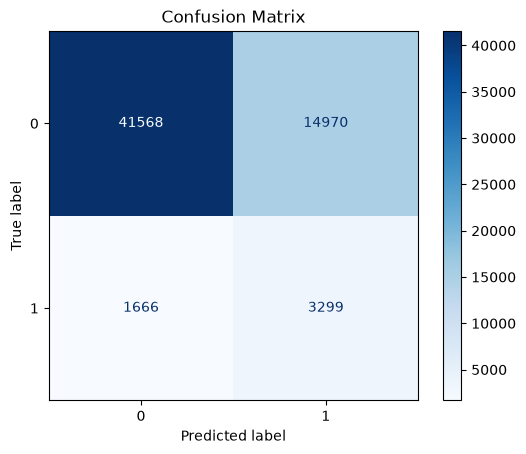

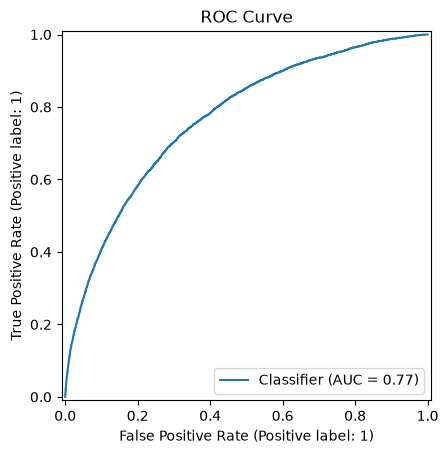

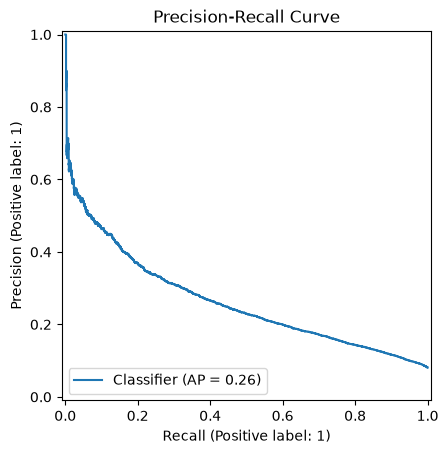

In [10]:
lightgbm_results = evaluate_model(
    lightgbm_pipeline,
    X_train,
    X_test,
    y_train,
    y_test
)

In [11]:
from src.evaluation import cross_validation_score

lightgbm_cv = cross_validation_score(
    lightgbm_pipeline,
    X_train,
    y_train
)

5-FOLD STRATIFIED CROSS VALIDATION
[0.7604062  0.76352474 0.76428871 0.76350075 0.76058913]

Mean ROC-AUC : 0.7625
Std Dev      : 0.0016


In [12]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E12",

    "Model": "LightGBM",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": lightgbm_results["accuracy"],

    "Precision": lightgbm_results["precision"],

    "Recall": lightgbm_results["recall"],

    "F1": lightgbm_results["f1"],

    "ROC_AUC": lightgbm_results["roc_auc"],

    "CV_ROC_AUC": lightgbm_cv.mean(),

    "Comments": "Baseline LightGBM"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
8,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
9,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized


## Experiment E12 Analysis

### Objective

Evaluate the baseline LightGBM model and compare its performance with previously developed machine learning models.

### Results

- Accuracy: **72.95%**
- Precision: **18.06%**
- Recall: **66.45%**
- F1 Score: **28.40%**
- ROC-AUC: **0.7690**
- Cross Validation ROC-AUC: **0.7625**

### Business Interpretation

The baseline LightGBM model demonstrated competitive ranking performance while significantly improving Recall compared to the baseline XGBoost model.

Although Precision is relatively low, the model successfully identifies a large proportion of defaulting customers, making it suitable for further optimization.

### Conclusion

Baseline LightGBM achieved competitive ROC-AUC and strong Recall. Hyperparameter tuning will be performed in the next experiment to improve Precision and overall classification performance while maintaining its ability to detect defaulting customers.

# Experiment E13 - Optimized LightGBM

## Objective

The baseline LightGBM model demonstrated strong Recall and competitive ROC-AUC compared to the optimized XGBoost model. However, the baseline model produced a relatively low Precision, indicating a high number of false positive predictions.

This experiment focuses on optimizing the LightGBM model using RandomizedSearchCV to improve its probability ranking, generalization capability, and overall predictive performance.

The optimized model will be evaluated using the standardized evaluation framework and compared against all previously developed machine learning models.

In [17]:
from sklearn.model_selection import RandomizedSearchCV

In [15]:
lightgbm_param_grid = {

    "classifier__n_estimators": [
        200,
        300,
        500
    ],

    "classifier__learning_rate": [
        0.01,
        0.05,
        0.1,
        0.2
    ],

    "classifier__num_leaves": [
        15,
        31,
        63,
        127
    ],

    "classifier__max_depth": [
        -1,
        5,
        7,
        10
    ],

    "classifier__min_child_samples": [
        10,
        20,
        50
    ],

    "classifier__subsample": [
        0.6,
        0.8,
        1.0
    ],

    "classifier__colsample_bytree": [
        0.6,
        0.8,
        1.0
    ]
}

In [18]:
lightgbm_search = RandomizedSearchCV(

    estimator=lightgbm_pipeline,

    param_distributions=lightgbm_param_grid,

    n_iter=15,

    scoring="roc_auc",

    cv=3,

    random_state=RANDOM_STATE,

    n_jobs=1,

    verbose=2

)

In [19]:
lightgbm_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=10, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time=  36.5s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=10, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time= 2.2min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=10, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time= 1.4min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.01, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=31, classifier__subsample=0.8; total time= 1.8min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.01, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=31, classifier__subsample=0.8; total time=  50.3s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.01, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=31, classifier__subsample=0.8; total time= 1.3min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=-1, classifier__min_child_samples=20, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time= 1.1min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=-1, classifier__min_child_samples=20, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time= 1.0min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=-1, classifier__min_child_samples=20, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time= 1.4min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=-1, classifier__min_child_samples=10, classifier__n_estimators=500, classifier__num_leaves=127, classifier__subsample=0.8; total time=  54.2s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=-1, classifier__min_child_samples=10, classifier__n_estimators=500, classifier__num_leaves=127, classifier__subsample=0.8; total time= 3.2min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=-1, classifier__min_child_samples=10, classifier__n_estimators=500, classifier__num_leaves=127, classifier__subsample=0.8; total time= 1.4min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=-1, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=127, classifier__subsample=0.8; total time= 1.6min


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=-1, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=127, classifier__subsample=0.8; total time=  48.8s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.1, classifier__max_depth=-1, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=127, classifier__subsample=0.8; total time=  45.3s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=15, classifier__subsample=0.6; total time=  20.0s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=15, classifier__subsample=0.6; total time=  23.8s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=15, classifier__subsample=0.6; total time=  24.6s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=5, classifier__min_child_samples=20, classifier__n_estimators=200, classifier__num_leaves=31, classifier__subsample=0.6; total time=  18.6s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=5, classifier__min_child_samples=20, classifier__n_estimators=200, classifier__num_leaves=31, classifier__subsample=0.6; total time=  18.2s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.2, classifier__max_depth=5, classifier__min_child_samples=20, classifier__n_estimators=200, classifier__num_leaves=31, classifier__subsample=0.6; total time=  20.3s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=10, classifier__min_child_samples=10, classifier__n_estimators=200, classifier__num_leaves=31, classifier__subsample=0.6; total time=  19.1s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=10, classifier__min_child_samples=10, classifier__n_estimators=200, classifier__num_leaves=31, classifier__subsample=0.6; total time=  19.6s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__max_depth=10, classifier__min_child_samples=10, classifier__n_estimators=200, classifier__num_leaves=31, classifier__subsample=0.6; total time=  19.1s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.01, classifier__max_depth=5, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=127, classifier__subsample=0.8; total time=  23.5s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.01, classifier__max_depth=5, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=127, classifier__subsample=0.8; total time=  23.7s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.01, classifier__max_depth=5, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=127, classifier__subsample=0.8; total time=  23.0s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_samples=20, classifier__n_estimators=500, classifier__num_leaves=31, classifier__subsample=1.0; total time=  21.2s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_samples=20, classifier__n_estimators=500, classifier__num_leaves=31, classifier__subsample=1.0; total time=  28.3s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.2, classifier__max_depth=10, classifier__min_child_samples=20, classifier__n_estimators=500, classifier__num_leaves=31, classifier__subsample=1.0; total time=  27.7s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=10, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=15, classifier__subsample=0.8; total time=  22.6s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=10, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=15, classifier__subsample=0.8; total time=  22.6s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.05, classifier__max_depth=10, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=15, classifier__subsample=0.8; total time=  23.2s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=31, classifier__subsample=0.6; total time=  22.7s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=31, classifier__subsample=0.6; total time=  24.0s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__min_child_samples=10, classifier__n_estimators=300, classifier__num_leaves=31, classifier__subsample=0.6; total time=  23.1s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__min_child_samples=20, classifier__n_estimators=300, classifier__num_leaves=127, classifier__subsample=0.6; total time=  26.5s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__min_child_samples=20, classifier__n_estimators=300, classifier__num_leaves=127, classifier__subsample=0.6; total time=  26.2s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__max_depth=7, classifier__min_child_samples=20, classifier__n_estimators=300, classifier__num_leaves=127, classifier__subsample=0.6; total time=  26.2s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.2, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=200, classifier__num_leaves=127, classifier__subsample=1.0; total time=  21.3s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.2, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=200, classifier__num_leaves=127, classifier__subsample=1.0; total time=  21.1s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=1.0, classifier__learning_rate=0.2, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=200, classifier__num_leaves=127, classifier__subsample=1.0; total time=  21.6s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.1, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time=  28.6s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.1, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time=  25.1s


c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END classifier__colsample_bytree=0.6, classifier__learning_rate=0.1, classifier__max_depth=7, classifier__min_child_samples=50, classifier__n_estimators=500, classifier__num_leaves=63, classifier__subsample=1.0; total time=  31.3s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...rbosity=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.6, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [-1, 5, ...], 'classifier__min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a be

In [20]:
print("=" * 60)
print("BEST PARAMETERS")
print("=" * 60)

print(lightgbm_search.best_params_)

BEST PARAMETERS
{'classifier__subsample': 0.6, 'classifier__num_leaves': 31, 'classifier__n_estimators': 300, 'classifier__min_child_samples': 10, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.8}


In [21]:
print("=" * 60)
print("BEST CROSS VALIDATION ROC-AUC")
print("=" * 60)

print(lightgbm_search.best_score_)

BEST CROSS VALIDATION ROC-AUC
0.7630900390997611


In [22]:
best_lightgbm = lightgbm_search.best_estimator_

c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LGBMClassifier
Accuracy : 0.7245
Precision: 0.1790
Recall   : 0.6729
F1 Score : 0.2828
ROC AUC  : 0.7690


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56538
           1       0.18      0.67      0.28      4965

    accuracy                           0.72     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.72      0.79     61503



<Figure size 600x500 with 0 Axes>

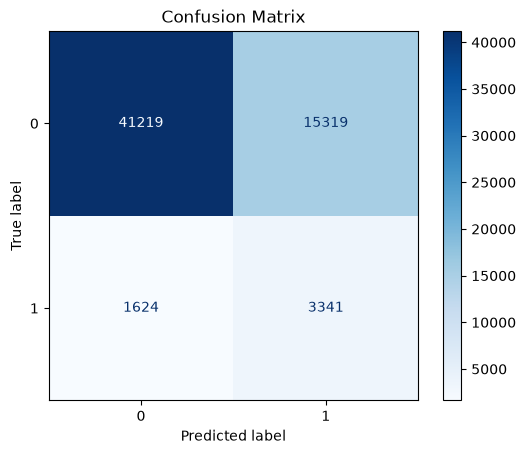

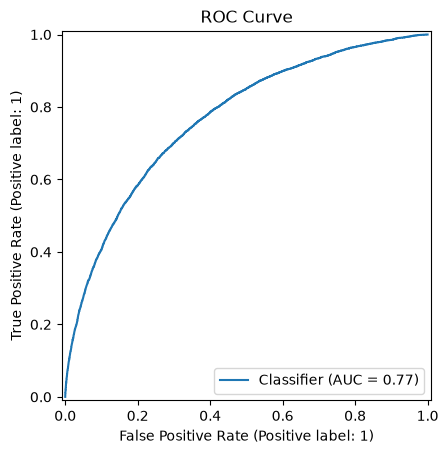

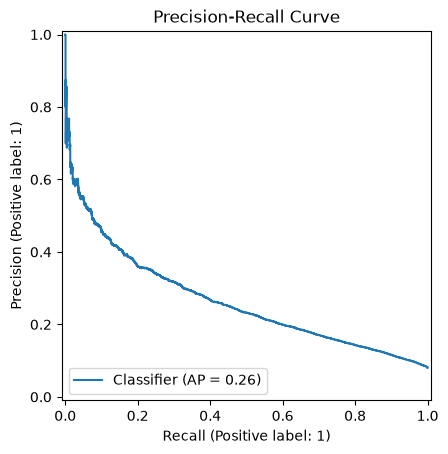

In [23]:
lightgbm_optimized_results = evaluate_model(
    best_lightgbm,
    X_train,
    X_test,
    y_train,
    y_test
)

In [25]:
lightgbm_optimized_cv = cross_validation_score(
    best_lightgbm,
    X_train,
    y_train
)

5-FOLD STRATIFIED CROSS VALIDATION
[0.76251577 0.76613871 0.76586037 0.76642924 0.76251494]

Mean ROC-AUC : 0.7647
Std Dev      : 0.0018


In [26]:
experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E13",

    "Model": "LightGBM (Optimized)",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": lightgbm_optimized_results["accuracy"],

    "Precision": lightgbm_optimized_results["precision"],

    "Recall": lightgbm_optimized_results["recall"],

    "F1": lightgbm_optimized_results["f1"],

    "ROC_AUC": lightgbm_optimized_results["roc_auc"],

    "CV_ROC_AUC": lightgbm_optimized_cv.mean(),

    "Comments": "RandomizedSearchCV Optimized"

}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
8,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
9,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized


## Experiment E13 Analysis

### Objective

Optimize the LightGBM model using RandomizedSearchCV to improve ranking performance, generalization capability, and overall predictive performance.

### Results

- Accuracy: **72.45%**
- Precision: **17.90%**
- Recall: **67.29%**
- F1 Score: **28.28%**
- ROC-AUC: **0.7690**
- Cross Validation ROC-AUC: **0.7647**

### Business Interpretation

Hyperparameter tuning produced only marginal changes in model performance. The optimized model achieved a slightly higher Cross Validation ROC-AUC, indicating improved generalization, while maintaining similar classification performance to the baseline LightGBM model.

### Conclusion

The baseline LightGBM model was already well-configured for this dataset. Hyperparameter optimization resulted in only minor improvements, suggesting that further performance gains are more likely to come from decision threshold optimization rather than additional parameter tuning.

In [30]:
experiment_tracker.drop_duplicates(inplace=True)

In [31]:
experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
9,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized
10,E11,XGBoost (Optimized + Threshold = 0.15),No,No,0.849731,0.254731,0.447331,0.324613,0.771062,0.767162,Threshold Optimized (0.15)


# Experiment E14 - Threshold Optimization for Optimized LightGBM

## Objective

The optimized LightGBM model achieved strong Recall and competitive ROC-AUC after hyperparameter tuning. However, the default decision threshold of 0.50 may not represent the optimal operating point for credit risk prediction.

This experiment evaluates multiple probability thresholds to identify the threshold that provides the best trade-off between Precision and Recall.

The optimized threshold will be compared against all previously evaluated models to determine whether LightGBM can outperform the optimized XGBoost model for business deployment.

In [32]:
lightgbm_probabilities = best_lightgbm.predict_proba(
    X_test
)[:, 1]

c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [33]:
thresholds = [
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lightgbm_threshold_results = []

for threshold in thresholds:

    predictions = (
        lightgbm_probabilities >= threshold
    ).astype(int)

    lightgbm_threshold_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1 Score": f1_score(
            y_test,
            predictions
        )

    })

lightgbm_threshold_results = pd.DataFrame(
    lightgbm_threshold_results
)

lightgbm_threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.120482,0.083774,0.995770,0.154546
1,0.15,0.192121,0.089450,0.981269,0.163955
2,0.20,0.281710,0.097842,0.960725,0.177597
3,0.25,0.372128,0.107330,0.926284,0.192370
4,0.30,0.459278,0.119100,0.890836,0.210109
5,0.35,0.537779,0.131676,0.844713,0.227836
6,0.40,0.607840,0.145533,0.791944,0.245881
7,0.45,0.669447,0.160892,0.734139,0.263939
8,0.50,0.724518,0.179046,0.672910,0.282836
9,0.55,0.771247,0.198423,0.603223,0.298619


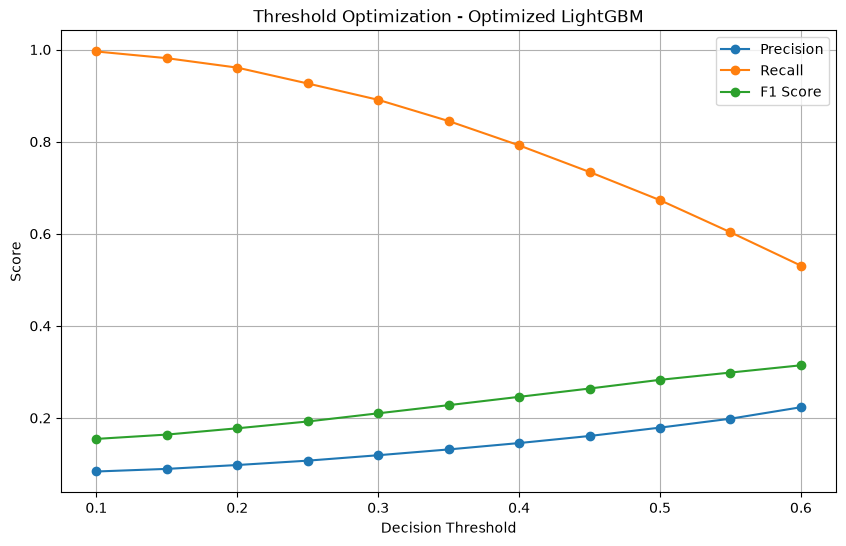

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    lightgbm_threshold_results["Threshold"],
    lightgbm_threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    lightgbm_threshold_results["Threshold"],
    lightgbm_threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    lightgbm_threshold_results["Threshold"],
    lightgbm_threshold_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization - Optimized LightGBM")

plt.grid(True)

plt.legend()

plt.show()

In [38]:
extended_thresholds = [
    0.60,
    0.65,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90
]

extended_results = []

for threshold in extended_thresholds:

    predictions = (
        lightgbm_probabilities >= threshold
    ).astype(int)

    extended_results.append({

        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions
        ),

        "F1 Score": f1_score(
            y_test,
            predictions
        )

    })

extended_results = pd.DataFrame(extended_results)

extended_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.60,0.813131,0.223343,0.530715,0.314383
1,0.65,0.848642,0.252450,0.446123,0.322440
2,0.70,0.875437,0.285214,0.360524,0.318477
3,0.75,0.897517,0.331656,0.265458,0.294888
4,0.80,0.911110,0.387343,0.173817,0.239956
5,0.85,0.918541,0.475623,0.088419,0.149117
6,0.90,0.919939,0.632258,0.019738,0.038281


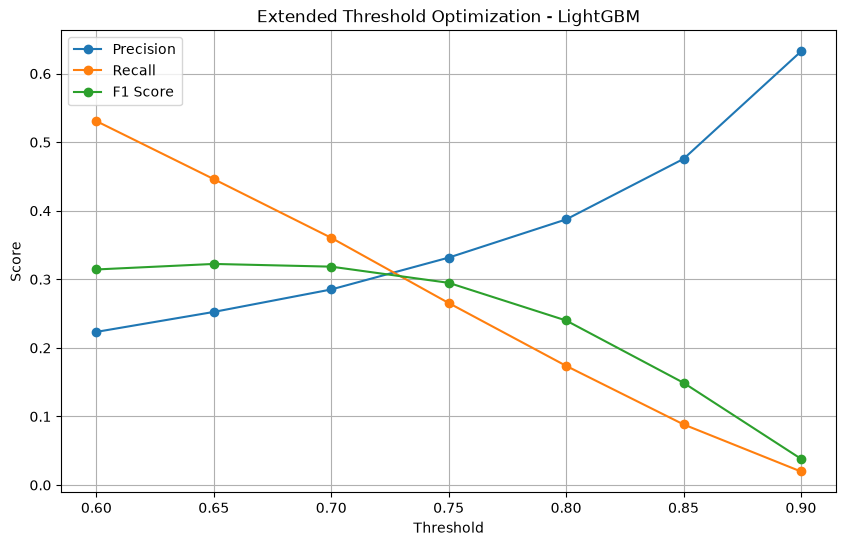

In [39]:
plt.figure(figsize=(10,6))

plt.plot(
    extended_results["Threshold"],
    extended_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    extended_results["Threshold"],
    extended_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    extended_results["Threshold"],
    extended_results["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.title("Extended Threshold Optimization - LightGBM")

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.grid(True)

plt.legend()

plt.show()

In [40]:
best_row = extended_results.loc[
    extended_results["F1 Score"].idxmax()
]

print("=" * 60)
print("BEST THRESHOLD")
print("=" * 60)

display(best_row)

BEST THRESHOLD


Threshold    0.650000
Accuracy     0.848642
Precision    0.252450
Recall       0.446123
F1 Score     0.322440
Name: 1, dtype: float64

In [41]:
lightgbm_threshold_results = pd.concat(
    [
        lightgbm_threshold_results,
        extended_results
    ],
    ignore_index=True
)

lightgbm_threshold_results.sort_values(
    "Threshold",
    inplace=True
)

lightgbm_threshold_results.reset_index(
    drop=True,
    inplace=True
)

lightgbm_threshold_results

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.120482,0.083774,0.995770,0.154546
1,0.15,0.192121,0.089450,0.981269,0.163955
2,0.20,0.281710,0.097842,0.960725,0.177597
3,0.25,0.372128,0.107330,0.926284,0.192370
4,0.30,0.459278,0.119100,0.890836,0.210109
5,0.35,0.537779,0.131676,0.844713,0.227836
6,0.40,0.607840,0.145533,0.791944,0.245881
7,0.45,0.669447,0.160892,0.734139,0.263939
8,0.50,0.724518,0.179046,0.672910,0.282836
9,0.55,0.771247,0.198423,0.603223,0.298619


In [44]:
best_threshold = 0.65

lightgbm_predictions = (
    lightgbm_probabilities >= best_threshold
).astype(int)

experiment_tracker.loc[len(experiment_tracker)] = {

    "Experiment": "E14",

    "Model": "LightGBM (Optimized + Threshold = 0.65)",

    "Scaling": "No",

    "SMOTE": "No",

    "Accuracy": accuracy_score(y_test, lightgbm_predictions),

    "Precision": precision_score(y_test, lightgbm_predictions),

    "Recall": recall_score(y_test, lightgbm_predictions),

    "F1": f1_score(y_test, lightgbm_predictions),

    "ROC_AUC": lightgbm_optimized_results["roc_auc"],

    "CV_ROC_AUC": lightgbm_optimized_cv.mean(),

    "Comments": "Threshold Optimized (0.65)"
}

experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
9,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized
10,E11,XGBoost (Optimized + Threshold = 0.15),No,No,0.849731,0.254731,0.447331,0.324613,0.771062,0.767162,Threshold Optimized (0.15)


## Experiment E14 Analysis

### Objective

Evaluate different decision thresholds for the optimized LightGBM model to identify the operating point that maximizes business performance.

### Results

The best-performing threshold was **0.65**.

- Accuracy: **84.86%**
- Precision: **25.25%**
- Recall: **44.61%**
- F1 Score: **32.24%**
- ROC-AUC: **0.7690**
- Cross Validation ROC-AUC: **0.7647**

### Business Interpretation

Increasing the decision threshold significantly improved Precision while reducing Recall. A threshold of **0.65** provided the best balance between identifying defaulting customers and minimizing false positive predictions.

### Conclusion

The optimized LightGBM model achieved performance comparable to the optimized XGBoost model. However, the optimized XGBoost model remained the strongest overall performer, achieving slightly higher ROC-AUC, Precision, Recall, and F1 Score.

In [45]:
joblib.dump(
    best_lightgbm,
    "../artifacts/models/lightgbm_optimized.pkl"
)

print("✅ Optimized LightGBM saved successfully.")

✅ Optimized LightGBM saved successfully.


In [46]:
joblib.dump(
    lightgbm_pipeline,
    "../artifacts/models/lightgbm_baseline.pkl"
)

print("✅ Baseline LightGBM saved successfully.")

✅ Baseline LightGBM saved successfully.


In [47]:
joblib.dump(
    lightgbm_search,
    "../artifacts/search_objects/lightgbm_search.pkl"
)

print("✅ LightGBM Search Object saved successfully.")

✅ LightGBM Search Object saved successfully.


In [48]:
best_lightgbm_threshold = 0.65

joblib.dump(
    best_lightgbm_threshold,
    "../artifacts/models/lightgbm_best_threshold.pkl"
)

print("✅ Best Threshold saved successfully.")

✅ Best Threshold saved successfully.


In [49]:
lightgbm_threshold_results.to_csv(
    "../artifacts/experiment_results/lightgbm_threshold_analysis.csv",
    index=False
)

print("✅ Threshold Analysis saved successfully.")

✅ Threshold Analysis saved successfully.


In [50]:
experiment_tracker.to_csv(
    "../artifacts/experiment_results/experiment_tracker.csv",
    index=False
)

print("✅ Experiment Tracker updated successfully.")

✅ Experiment Tracker updated successfully.


In [51]:
experiment_tracker.to_csv(
    "../artifacts/experiment_results/final_model_comparison.csv",
    index=False
)

print("✅ Final Model Comparison saved successfully.")

✅ Final Model Comparison saved successfully.


In [52]:
import os

print("=" * 70)
print("ARTIFACT VERIFICATION")
print("=" * 70)

folders = [
    "../artifacts/datasets",
    "../artifacts/preprocessors",
    "../artifacts/models",
    "../artifacts/search_objects",
    "../artifacts/experiment_results"
]

for folder in folders:
    print(f"\n📁 {folder}")
    for file in sorted(os.listdir(folder)):
        print(f"   ✅ {file}")

ARTIFACT VERIFICATION

📁 ../artifacts/datasets
   ✅ X_test.pkl
   ✅ X_train.pkl
   ✅ y_test.pkl
   ✅ y_train.pkl

📁 ../artifacts/preprocessors
   ✅ preprocessor.pkl

📁 ../artifacts/models
   ✅ decision_tree_optimized.pkl
   ✅ lightgbm_baseline.pkl
   ✅ lightgbm_best_threshold.pkl
   ✅ lightgbm_optimized.pkl
   ✅ logistic_regression_balanced.pkl
   ✅ random_forest_baseline.pkl
   ✅ random_forest_optimized.pkl
   ✅ xgboost_baseline.pkl
   ✅ xgboost_best_threshold.pkl
   ✅ xgboost_optimized.pkl

📁 ../artifacts/search_objects
   ✅ decision_tree_search.pkl
   ✅ lightgbm_search.pkl
   ✅ random_forest_search.pkl
   ✅ xgboost_search.pkl

📁 ../artifacts/experiment_results
   ✅ experiment_tracker.csv
   ✅ final_model_comparison.csv
   ✅ lightgbm_threshold_analysis.csv
   ✅ xgboost_optimized_threshold_analysis.csv
   ✅ xgboost_threshold_analysis.csv


In [53]:
import sys

print(sys.executable)

c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\venv\Scripts\python.exe


In [1]:
import pandas
import numpy
import matplotlib
import sklearn

print("Everything works!")

Everything works!


In [1]:
import joblib

X_train = joblib.load("../artifacts_local/datasets/X_train.pkl")

In [2]:
print(X_train.columns.tolist())

['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_

In [3]:
import joblib
import os

# Load test dataset
X_test = joblib.load("../artifacts_local/datasets/X_test.pkl")

# Create folder if it doesn't exist
os.makedirs("sample_data", exist_ok=True)

# Save first 100 rows as CSV
X_test.head(100).to_csv("sample_data/sample_input.csv", index=False)

print("✅ Sample CSV created successfully!")
print("Location: sample_data/sample_input.csv")

✅ Sample CSV created successfully!
Location: sample_data/sample_input.csv


In [2]:
import os

print(os.getcwd())

c:\HomeLoanDefaultPrediction\home-loan-default-risk-prediction\notebooks


In [4]:
[c for c in X_test.columns if "id" in c.lower()]

['DAYS_ID_PUBLISH']

In [16]:
import joblib
import pandas as pd

# Load original dataset
application_train = pd.read_csv("../artifacts_local/data_local/raw/application_train.csv")

# Load test features
X_test = joblib.load("../artifacts_local/datasets/X_test.pkl")

# Keep only the customer IDs for the test rows
customer_ids = application_train.loc[X_test.index, ["SK_ID_CURR"]]

# Combine ID with feature set
sample_input = pd.concat([customer_ids.reset_index(drop=True),
                          X_test.reset_index(drop=True)], axis=1)

sample_input.to_csv("../notebooks/sample_data/sample_input.csv", index=False)

In [18]:
import joblib
from pathlib import Path

BASE_DIR = Path("..")   # because notebook is inside notebooks/

# Load production model
model = joblib.load(BASE_DIR / "artifacts/models/xgboost_optimized.pkl")

# Load threshold
threshold = joblib.load(BASE_DIR / "artifacts/models/xgboost_best_threshold.pkl")

# Load test data
X_test = joblib.load(BASE_DIR / "artifacts_local/datasets/X_test.pkl")
y_test = joblib.load(BASE_DIR / "artifacts_local/datasets/y_test.pkl")

C:\Users\Shambhu\AppData\Local\Programs\Python\Python311\Lib\pickle.py:1718: UserWarning: [18:08:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [19]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= threshold).astype(int)

In [20]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

roc_auc = roc_auc_score(y_test, y_prob)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

In [21]:
print("ROC-AUC :", roc_auc)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

ROC-AUC : 0.7710618925495555
Accuracy: 0.8497309074354097
Precision: 0.2547310471384333
Recall: 0.4473313192346425
F1: 0.32461268634902074

TN: 50040
FP: 6498
FN: 2744
TP: 2221


In [22]:
import joblib

metrics = {
    "best_model": "XGBoost (Optimized + Threshold)",
    "threshold": threshold,

    "roc_auc": roc_auc,
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,

    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),

    "validation_size": len(y_test),
    "features": X_test.shape[1]
}

In [23]:
joblib.dump(
    metrics,
    "../artifacts/experiment_results/final_metrics.pkl"
)

print("Saved successfully!")

Saved successfully!


In [3]:
import joblib
loaded = joblib.load("../artifacts/experiment_results/final_metrics.pkl")

loaded

{'best_model': 'XGBoost (Optimized + Threshold)',
 'threshold': 0.15,
 'roc_auc': 0.7710618925495555,
 'accuracy': 0.8497309074354097,
 'precision': 0.2547310471384333,
 'recall': 0.4473313192346425,
 'f1': 0.32461268634902074,
 'tn': 50040,
 'fp': 6498,
 'fn': 2744,
 'tp': 2221,
 'validation_size': 61503,
 'features': 143}

In [7]:
import pandas as pd
final_model_results = pd.read_csv("../artifacts/experiment_results/final_model_comparison.csv")
final_model_results.head()

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest


In [10]:
experiment_tracker = pd.read_csv("../artifacts/experiment_results/experiment_tracker.csv")
experiment_tracker

,Experiment,Model,Scaling,SMOTE,Accuracy,Precision,Recall,F1,ROC_AUC,CV_ROC_AUC,Comments
0,E1,Logistic Regression,Yes,No,0.919484,0.537572,0.018731,0.036201,0.758737,0.753831,Baseline Model
1,E2,Logistic Regression (Balanced),Yes,No,0.695999,0.166310,0.689225,0.267961,0.759027,0.754766,Applied class_weight='balanced'
2,E4,Decision Tree,No,No,0.854869,0.151872,0.174018,0.162193,0.544339,0.538856,Baseline Decision Tree
3,E5,Decision Tree (Optimized),No,No,0.596914,0.122276,0.646324,0.205646,0.662434,0.659850,RandomizedSearchCV Optimized
4,E6,Random Forest,No,No,0.917614,0.416118,0.050957,0.090795,0.749350,0.744221,Baseline Random Forest
5,E7,Random Forest (Optimized),No,No,0.919288,1.000000,0.000201,0.000403,0.751658,0.750335,RandomizedSearchCV Optimized
6,E8,XGBoost,No,No,0.919727,0.545161,0.034038,0.064076,0.768586,0.763773,Baseline XGBoost
7,E9,XGBoost (Threshold = 0.20),No,No,0.886168,0.305873,0.323061,0.314233,0.768586,0.763773,Threshold Optimized (0.20)
8,E10,XGBoost (Optimized),No,No,0.920004,0.579505,0.033031,0.062500,0.771062,0.767162,RandomizedSearchCV Optimized
9,E11,XGBoost (Optimized + Threshold = 0.15),No,No,0.849731,0.254731,0.447331,0.324613,0.771062,0.767162,Threshold Optimized (0.15)


In [12]:
from pathlib import Path

BASE_DIR = Path("..")

In [13]:

experiment_tracker = pd.read_csv(
    BASE_DIR / "artifacts/experiment_results/experiment_tracker.csv"
)

model_data = experiment_tracker[
    [
        "Model",
        "ROC_AUC",
        "F1",
        "Accuracy"
    ]
].copy()

In [14]:
model_data.rename(
    columns={
        "ROC_AUC": "ROC-AUC"
    },
    inplace=True
)

In [16]:
import joblib

metrics = joblib.load(
    BASE_DIR / "artifacts/experiment_results/final_metrics.pkl"
)

In [17]:
model_data["best"] = (
    model_data["Model"] == metrics["best_model"]
)

In [18]:
metrics

{'best_model': 'XGBoost (Optimized + Threshold)',
 'threshold': 0.15,
 'roc_auc': 0.7710618925495555,
 'accuracy': 0.8497309074354097,
 'precision': 0.2547310471384333,
 'recall': 0.4473313192346425,
 'f1': 0.32461268634902074,
 'tn': 50040,
 'fp': 6498,
 'fn': 2744,
 'tp': 2221,
 'validation_size': 61503,
 'features': 143}

In [19]:
model_data["best"] = (
    model_data["Model"] == metrics["best_model"]
)

In [20]:
best_model = metrics["best_model"]

model_data["best"] = model_data["Model"].eq(best_model)